# Show, Attend and Tell: Neural Image Caption Generation with Visual Attention

**Authors:** Kelvin Xu, Jimmy Lei Ba, Ryan Kiros, Kyunghyun Cho, Aaron Courville, Ruslan Salakhutdinov, Richard S. Zemel, Yoshua Bengio
**Venue:** ICML 2015 (arXiv:1502.03044v3)

# https://arxiv.org/pdf/1502.03044

---

## Abstract

This paper introduces an attention-based neural network model for automatic image caption
generation. The model learns to selectively focus on salient spatial regions of an image while
generating each word in the output caption. Two attention variants are proposed: a soft
deterministic mechanism trained via standard backpropagation, and a hard stochastic mechanism
trained by maximizing a variational lower bound using REINFORCE. The model achieves
state-of-the-art performance on Flickr8k, Flickr30k, and MS COCO benchmarks and provides
interpretable visualizations of learned image-language alignments.

---

## Problems

- Prior image captioning models encode an entire image into a single fixed-length feature vector
  (typically from the top layer of a CNN), discarding spatial structure and fine-grained visual
  detail.
- Compressing a full image into one static representation causes information loss, particularly
  for richer, more descriptive captions.
- Models lack interpretability: it is unclear which image regions contribute to each generated
  word.
- Without a spatial focusing mechanism, the decoder cannot dynamically route attention to the
  most relevant parts of the image during sequential word generation.

---

## Proposed Solutions

- Replace the global image vector with a set of **annotation vectors** extracted from a lower
  convolutional layer, preserving spatial correspondence.
- Introduce an **attention mechanism** that computes a dynamic context vector at each decoding
  step by weighting the spatial annotation vectors.
- Propose two attention formulations:
  - **Soft Attention:** Deterministic weighted sum over all spatial locations; end-to-end
    differentiable.
  - **Hard Attention:** Stochastic selection of a single spatial location; trained via
    REINFORCE with variance reduction.
- Apply **doubly stochastic regularization** to encourage the model to attend to all image
  regions over the course of caption generation.

---

## Purpose

- To improve the quality and descriptiveness of automatically generated image captions by
  incorporating a spatial attention mechanism into the encoder-decoder framework.
- To enable interpretability by visualizing which image regions the model attends to when
  generating each word.
- To demonstrate that attention-based alignment can be learned from scratch without explicit
  object detection supervision.

---

## Methodology

### Encoder: Convolutional Feature Extraction

A pre-trained **Oxford VGGNet** (19-layer) extracts spatial feature maps from the fourth
convolutional layer before max pooling, yielding:

$$a = \{a_1, \dots, a_L\}, \quad a_i \in \mathbb{R}^D$$

where $L = 196$ spatial locations and $D = 512$ channels, giving a $196 \times 512$ annotation
matrix.

### Decoder: LSTM with Attention

At each time step $t$, the LSTM receives the previous hidden state $h_{t-1}$, the previous
word embedding $Ey_{t-1}$, and a context vector $\hat{z}_t$:

$$\begin{pmatrix} i_t \\ f_t \\ o_t \\ g_t \end{pmatrix} = \begin{pmatrix} \sigma \\ \sigma \\ \sigma \\ \tanh \end{pmatrix} T_{D+m+n,n} \begin{pmatrix} Ey_{t-1} \\ h_{t-1} \\ \hat{z}_t \end{pmatrix}$$

$$c_t = f_t \odot c_{t-1} + i_t \odot g_t, \qquad h_t = o_t \odot \tanh(c_t)$$

### Attention Mechanism

An attention network $f_{\text{att}}$ scores each annotation vector against the previous hidden
state:

$$e_{ti} = f_{\text{att}}(a_i, h_{t-1}), \qquad \alpha_{ti} = \frac{\exp(e_{ti})}{\sum_{k=1}^{L} \exp(e_{tk})}$$

#### Soft Attention (Deterministic)

$$\hat{z}_t = \phi(\{a_i\}, \{\alpha_i\}) = \sum_{i=1}^{L} \alpha_{ti} a_i$$

Trained end-to-end via backpropagation. Doubly stochastic regularization penalizes deviation
from uniform coverage:

$$\mathcal{L}_d = -\log P(y|x) + \lambda \sum_{i=1}^{L} \left(1 - \sum_{t=1}^{C} \alpha_{ti}\right)^2$$

#### Hard Attention (Stochastic)

The location $s_t$ is sampled from a Multinoulli distribution parameterized by $\{\alpha_i\}$:

$$p(s_{t,i} = 1 \mid s_{j < t}, a) = \alpha_{t,i}, \qquad \hat{z}_t = \sum_i s_{t,i} a_i$$

Optimized by maximizing a variational lower bound using REINFORCE with a moving average
baseline and entropy regularization:

$$b_k = 0.9 \times b_{k-1} + 0.1 \times \log p(y \mid \tilde{s}_k, a)$$

### Output Distribution

A deep output layer computes word probabilities:

$$p(y_t \mid a, y_{1}^{t-1}) \propto \exp\!\left(L_o(Ey_{t-1} + L_h h_t + L_z \hat{z}_t)\right)$$

### Training Details

| Component         | Detail                                      |
|-------------------|---------------------------------------------|
| CNN Encoder       | Oxford VGGNet (19-layer), ImageNet pretrained, frozen |
| Feature Map       | $14 \times 14 \times 512$ (Layer 4, pre-pooling) |
| LSTM              | Single-layer with deep output               |
| Optimizer         | RMSProp (Flickr8k), Adam (Flickr30k, COCO)  |
| Batch Size        | 64 (length-bucketed sampling)               |
| Regularization    | Dropout, early stopping on BLEU, doubly stochastic penalty |
| Training Time     | $< 3$ days on NVIDIA Titan Black (MS COCO, soft attention) |
| Vocabulary Size   | 10,000 tokens                               |

### Datasets and Evaluation

| Dataset    | Images  | References/Image |
|------------|---------|-----------------|
| Flickr8k   | 8,000   | 5               |
| Flickr30k  | 30,000  | 5               |
| MS COCO    | 82,783  | $\geq 5$        |

Evaluation metrics: **BLEU-1 through BLEU-4**, **METEOR**.

---

## Results

### Quantitative Performance (Selected)

| Dataset   | Model          | BLEU-1 | BLEU-2 | BLEU-3 | BLEU-4 | METEOR |
|-----------|----------------|--------|--------|--------|--------|--------|
| Flickr8k  | Soft-Attention | 67.0   | 44.8   | 29.9   | 19.5   | 18.93  |
| Flickr8k  | Hard-Attention | 67.0   | 45.7   | 31.4   | 21.3   | 20.30  |
| Flickr30k | Soft-Attention | 66.7   | 43.4   | 28.8   | 19.1   | 18.49  |
| Flickr30k | Hard-Attention | 66.9   | 43.9   | 29.6   | 19.9   | 18.46  |
| MS COCO   | Soft-Attention | 70.7   | 49.2   | 34.4   | 24.3   | 23.90  |
| MS COCO   | Hard-Attention | 71.8   | 50.4   | 35.7   | 25.0   | 23.04  |

- Both attention models outperform Google NIC (Vinyals et al., 2014) and Log-Bilinear
  (Kiros et al., 2014) baselines across all datasets.
- Hard attention achieves higher BLEU scores; soft attention achieves higher METEOR on COCO.
- Results are obtained with a **single model** (no ensembling), unlike several baselines.

### Qualitative Findings

- Attention maps show semantically coherent alignment: the model focuses on objects
  corresponding to the word being generated (e.g., "bird," "frisbee," "surfboard").
- Error analysis via attention visualization reveals interpretable failure modes, such as
  misidentifying objects in cluttered or ambiguous scenes.
- Doubly stochastic regularization empirically improves both BLEU scores and caption richness.

---

## Conclusions

- Spatial attention integrated into an encoder-decoder captioning framework yields
  state-of-the-art results on three standard benchmarks using a single model.
- The soft attention mechanism is fully differentiable and practical; hard attention provides
  complementary performance gains at the cost of higher training complexity.
- Attention enables model interpretability by revealing which spatial regions drive each word
  prediction, aligning closely with human intuition.
- The framework learns visual-linguistic alignments from scratch without explicit object
  detection, demonstrating that attention can generalize beyond named object categories to
  abstract or relational concepts.
- The modular encoder-decoder-attention design is domain-agnostic and applicable to other
  sequence generation tasks involving structured input signals.

# Mathematical and Statistical Content: Show, Attend and Tell

---

## 1. Caption Representation

$$y = \{y_1, \dots, y_C\}, \quad y_i \in \mathbb{R}^K$$

The caption is a sequence of $C$ words. Each word $y_i$ is a one-hot vector of length $K$,
where $K$ is the vocabulary size. This is the standard discrete representation of text used
as the decoder target.

---

## 2. Annotation Vectors (Spatial CNN Features)

$$a = \{a_1, \dots, a_L\}, \quad a_i \in \mathbb{R}^D$$

The encoder CNN produces $L$ feature vectors, each of dimension $D$, corresponding to
distinct spatial regions of the image. Unlike a single global vector, this set preserves
spatial structure, allowing the decoder to selectively access different parts of the image.
In practice, $L = 196$ (a $14 \times 14$ grid) and $D = 512$.

---

## 3. LSTM Equations

The decoder is a Long Short-Term Memory network. At each time step $t$:

$$\begin{pmatrix} i_t \\ f_t \\ o_t \\ g_t \end{pmatrix} =
\begin{pmatrix} \sigma \\ \sigma \\ \sigma \\ \tanh \end{pmatrix}
T_{D+m+n,\, n}
\begin{pmatrix} Ey_{t-1} \\ h_{t-1} \\ \hat{z}_t \end{pmatrix}$$

$$c_t = f_t \odot c_{t-1} + i_t \odot g_t$$

$$h_t = o_t \odot \tanh(c_t)$$

**Term-by-term explanation:**

| Symbol        | Meaning                                              |
|---------------|------------------------------------------------------|
| $i_t$         | Input gate: controls how much new info enters memory |
| $f_t$         | Forget gate: controls how much old memory is erased  |
| $o_t$         | Output gate: controls what memory is exposed         |
| $g_t$         | Input modulator: candidate values to add to memory   |
| $c_t$         | Memory cell: the internal long-term state            |
| $h_t$         | Hidden state: the output used for word prediction    |
| $E$           | Word embedding matrix, $E \in \mathbb{R}^{m \times K}$ |
| $\hat{z}_t$   | Context vector from attention (see below)            |
| $\odot$       | Element-wise (Hadamard) multiplication               |
| $\sigma$      | Sigmoid activation, squashes values to $(0, 1)$      |
| $T_{D+m+n,n}$ | Learned affine transformation mapping inputs to gates|

The input to the LSTM at each step is the concatenation of the previous word embedding
$Ey_{t-1}$, the previous hidden state $h_{t-1}$, and the attention context vector
$\hat{z}_t$. The memory cell $c_t$ is the gated combination of the old memory and new input.

---

## 4. LSTM Initialization

$$c_0 = f_{\text{init},c}\!\left(\frac{1}{L}\sum_{i=1}^{L} a_i\right), \qquad
h_0 = f_{\text{init},h}\!\left(\frac{1}{L}\sum_{i=1}^{L} a_i\right)$$

The LSTM hidden and memory states are initialized using the mean of all annotation vectors,
passed through separate small MLPs. This gives the decoder a global summary of the image
as its starting state before generation begins.

---

## 5. Attention Energy Scores

$$e_{ti} = f_{\text{att}}(a_i,\, h_{t-1})$$

For each spatial location $i$ and time step $t$, an attention MLP computes a scalar energy
score $e_{ti}$. This score measures how relevant spatial region $i$ is for generating the
next word, given the current decoder state $h_{t-1}$. Higher energy means the region is
more useful at this decoding step.

---

## 6. Attention Weights (Softmax Normalization)

$$\alpha_{ti} = \frac{\exp(e_{ti})}{\sum_{k=1}^{L} \exp(e_{tk})}$$

The raw energy scores are converted into a proper probability distribution over $L$ spatial
locations using softmax. The weights $\alpha_{ti}$ sum to 1 and represent the relative
importance of each image region at time step $t$. This is the core of the attention mechanism.

---

## 7. Context Vector Computation

$$\hat{z}_t = \phi\!\left(\{a_i\},\, \{\alpha_i\}\right)$$

The function $\phi$ combines the annotation vectors and their attention weights to produce
a single context vector $\hat{z}_t \in \mathbb{R}^D$. The two variants differ in how $\phi$
is defined.

---

## 8. Soft (Deterministic) Attention

$$\hat{z}_t = \sum_{i=1}^{L} \alpha_{ti}\, a_i$$

The context vector is the weighted average of all annotation vectors. Every spatial region
contributes proportionally to its attention weight. Because this operation is a smooth,
differentiable weighted sum, the entire model can be trained end-to-end with standard
backpropagation. No sampling is required.

---

## 9. Hard (Stochastic) Attention

$$p(s_{t,i} = 1 \mid s_{j < t},\, a) = \alpha_{t,i}$$

$$\hat{z}_t = \sum_i s_{t,i}\, a_i$$

Instead of a weighted average, hard attention samples a single location $s_t$ from a
Multinoulli distribution parameterized by $\{\alpha_i\}$. The indicator variable $s_{t,i}$
is 1 for the chosen location and 0 elsewhere, so $\hat{z}_t$ equals exactly one annotation
vector $a_i$. This is non-differentiable, requiring a different training strategy.

---

## 10. Variational Lower Bound (Hard Attention Objective)

$$\mathcal{L}_s = \sum_s p(s \mid a) \log p(y \mid s, a) \leq \log \sum_s p(s \mid a)\, p(y \mid s, a) = \log p(y \mid a)$$

Since exact marginalization over all possible attention paths $s$ is intractable, the model
maximizes $\mathcal{L}_s$, a variational lower bound on the true log-likelihood
$\log p(y \mid a)$. Maximizing a lower bound on the objective is a standard technique in
probabilistic inference (analogous to the ELBO in variational autoencoders).

---

## 11. REINFORCE Gradient Estimator

$$\frac{\partial \mathcal{L}_s}{\partial W} \approx
\frac{1}{N} \sum_{n=1}^{N}
\left[
\frac{\partial \log p(y \mid \tilde{s}^n, a)}{\partial W} +
\log p(y \mid \tilde{s}^n, a)\,
\frac{\partial \log p(\tilde{s}^n \mid a)}{\partial W}
\right]$$

Because hard attention involves discrete sampling (non-differentiable), gradients are
estimated using the REINFORCE policy gradient algorithm. $N$ attention trajectories
$\tilde{s}^n$ are sampled from the Multinoulli distribution; the gradient is a Monte Carlo
average over these samples. The second term acts as a reinforcement signal: attention
trajectories that lead to better captions receive larger gradient updates.

---

## 12. Moving Average Baseline (Variance Reduction)

$$b_k = 0.9 \times b_{k-1} + 0.1 \times \log p(y \mid \tilde{s}_k, a)$$

REINFORCE estimators suffer from high variance. A moving average baseline $b_k$ is
subtracted from the reward signal to reduce variance without introducing bias. The
exponential smoothing (weight 0.9 on the past, 0.1 on the current batch) tracks the
recent average log-likelihood and stabilizes training.

---

## 13. Final Hard Attention Learning Rule

$$\frac{\partial \mathcal{L}_s}{\partial W} \approx
\frac{1}{N} \sum_{n=1}^{N}
\left[
\frac{\partial \log p(y \mid \tilde{s}^n, a)}{\partial W}
+ \lambda_r \bigl(\log p(y \mid \tilde{s}^n, a) - b\bigr)
\frac{\partial \log p(\tilde{s}^n \mid a)}{\partial W}
+ \lambda_e \frac{\partial \mathcal{H}[\tilde{s}^n]}{\partial W}
\right]$$

Three components are combined:

| Term                   | Role                                                      |
|------------------------|-----------------------------------------------------------|
| First term             | Standard cross-entropy gradient (MLE on captions)         |
| Second term ($\lambda_r$) | REINFORCE reward signal with baseline subtraction      |
| Third term ($\lambda_e$)  | Entropy bonus $\mathcal{H}[\tilde{s}^n]$ encouraging exploration of attention locations |

$\lambda_r$ and $\lambda_e$ are hyperparameters set by cross-validation. The entropy term
prevents the attention distribution from collapsing to a single location prematurely.

---

## 14. Output Word Probability

$$p(y_t \mid a,\, y_1^{t-1}) \propto \exp\!\left(L_o\bigl(Ey_{t-1} + L_h h_t + L_z \hat{z}_t\bigr)\right)$$

The probability of generating word $y_t$ depends on three sources of information:
the previous word embedding $Ey_{t-1}$, the LSTM hidden state $h_t$, and the attention
context $\hat{z}_t$. Learned projection matrices $L_o \in \mathbb{R}^{K \times m}$,
$L_h \in \mathbb{R}^{m \times n}$, and $L_z \in \mathbb{R}^{m \times D}$ map these into
a vocabulary-sized logit vector, which is passed through softmax to produce a distribution
over the next word. This is called a deep output layer.

---

## 15. Doubly Stochastic Regularization

By the softmax construction:

$$\sum_{i=1}^{L} \alpha_{ti} = 1 \quad \forall\, t$$

The paper additionally encourages:

$$\sum_{t=1}^{C} \alpha_{ti} \approx 1 \quad \forall\, i$$

This second constraint means each spatial location should receive roughly equal total
attention summed across all time steps, i.e., the model should inspect every part of the
image at least once during caption generation. This is enforced by the penalized loss:

$$\mathcal{L}_d = -\log P(y \mid x) + \lambda \sum_{i=1}^{L}
\left(1 - \sum_{t=1}^{C} \alpha_{ti}\right)^2$$

The penalty is the squared deviation from uniform coverage, weighted by $\lambda$.
Empirically this improves BLEU scores and caption richness.

---

## 16. Gating Scalar (Soft Attention Extension)

$$\hat{z}_t = \beta_t \sum_{i=1}^{L} \alpha_{ti}\, a_i, \qquad
\beta_t = \sigma\!\left(f_\beta(h_{t-1})\right)$$

A scalar gate $\beta_t \in (0,1)$, predicted from the previous hidden state, modulates
the overall magnitude of the context vector. It allows the model to learn how much the
visual context should influence the current decoding step, giving it the flexibility to
rely more on language context when the image adds little new information.

---

## 17. Normalized Weighted Geometric Mean (NWGM) Approximation

$$\text{NWGM}[p(y_t = k \mid a)] =
\frac{\prod_i \exp(n_{t,k,i})^{p(s_{t,i}=1 \mid a)}}
{\sum_j \prod_i \exp(n_{t,j,i})^{p(s_{t,i}=1 \mid a)}}
= \frac{\exp\!\left(\mathbb{E}_{p(s_t \mid a)}[n_{t,k}]\right)}
{\sum_j \exp\!\left(\mathbb{E}_{p(s_t \mid a)}[n_{t,j}]\right)}$$

This result justifies soft attention as an approximation to the full expectation over all
hard attention locations. It shows that applying softmax to the expected logits
(as soft attention does) approximates the true expected output probability under hard
attention, via a first-order Taylor expansion of the LSTM and the identity
$\text{NWGM}[p] \approx \mathbb{E}[p]$ under softmax activations (Baldi & Sadowski, 2014).

---

## 18. Evaluation Metrics

### BLEU (Bilingual Evaluation Understudy)

$$\text{BLEU-}n = \text{BP} \times \exp\!\left(\sum_{n=1}^{N} w_n \log p_n\right)$$

where $p_n$ is the modified $n$-gram precision between the generated caption and reference
captions, and BP is a brevity penalty for short outputs. The paper reports BLEU-1 through
BLEU-4 without brevity penalty. Higher BLEU indicates greater $n$-gram overlap with human
references.

### METEOR (Metric for Evaluation of Translation with Explicit Ordering)

METEOR computes an F-score between generated and reference captions using unigram matching
(with stemming and synonym matching), then applies a penalty for fragmented word order.
It correlates better with human judgment than BLEU at the sentence level and is reported
as a complementary metric.

---

## Summary Table of Key Mathematical Components

| Component                    | Type                        | Purpose                                      |
|------------------------------|-----------------------------|----------------------------------------------|
| Annotation vectors $a_i$     | Set of vectors              | Spatial image representation                 |
| Attention energy $e_{ti}$    | Scalar (MLP output)         | Location relevance score                     |
| Attention weights $\alpha_{ti}$ | Probability simplex      | Soft spatial selection                       |
| Context vector $\hat{z}_t$   | Weighted sum / sample       | Visual input to decoder at step $t$          |
| LSTM gates                   | Sigmoid/tanh nonlinearities | Gated memory update and retrieval            |
| Soft attention loss          | Cross-entropy + L2 penalty  | End-to-end differentiable training           |
| Variational lower bound      | Log-likelihood bound        | Tractable objective for hard attention       |
| REINFORCE estimator          | Monte Carlo gradient        | Gradient through discrete sampling           |
| Moving average baseline $b_k$| Exponential smoothing       | Variance reduction for REINFORCE             |
| Doubly stochastic penalty    | L2 regularization           | Full image coverage encouragement            |
| NWGM approximation           | First-order Taylor expansion| Theoretical justification for soft attention |
| BLEU / METEOR                | Corpus-level n-gram metrics | Caption quality evaluation                   |

# Problem–Gap–Solution Table: Show, Attend and Tell

---

| # | Problem / Research Gap | Limitation in Prior Work | Proposed Solution |
|---|------------------------|--------------------------|-------------------|
| 1 | **Global image encoding** — Prior models compress the entire image into a single fixed-length feature vector extracted from the top fully connected layer of a CNN. | A single global vector cannot preserve spatial or positional information about individual objects or regions, leading to loss of fine-grained visual detail critical for generating rich, descriptive captions. | Extract a set of $L = 196$ annotation vectors $\{a_1, \dots, a_L\}$, $a_i \in \mathbb{R}^D$, from a lower convolutional layer ($14 \times 14 \times 512$ feature map), preserving spatial correspondence between features and image regions. |
| 2 | **Static visual representation during decoding** — The image representation fed to the decoder remains fixed throughout the entire caption generation process. | The decoder cannot adjust which visual information it uses at each word generation step, making it difficult to describe multiple distinct objects or relationships within the same image. | Introduce a dynamic context vector $\hat{z}_t$ recomputed at each decoding step $t$ via an attention mechanism, allowing the model to selectively focus on different spatial regions as each word is generated. |
| 3 | **Lack of interpretability** — Prior encoder-decoder models provide no mechanism to identify which image regions influenced the generation of specific words. | It is impossible to audit model behavior, diagnose errors, or verify that the model is attending to semantically correct regions, limiting trust and analytical utility. | Visualize the attention weight maps $\{\alpha_{ti}\}$ at each time step to show which spatial regions the model attends to when generating each word, providing direct word-to-region alignment without requiring explicit object detection supervision. |
| 4 | **Reliance on explicit object detection** — Several prior captioning systems depend on pre-trained object detectors (e.g., R-CNN) to identify candidate alignment targets for image-text matching. | Object detectors constrain the model to predefined object categories, preventing it from attending to abstract, relational, or non-object visual concepts relevant to natural language description. | Learn latent visual-linguistic alignments entirely from scratch through the attention mechanism, enabling the model to attend to arbitrary salient regions beyond named object categories. |
| 5 | **Non-differentiable spatial selection** — Ideally, a model would make hard discrete choices about which image region to attend to, but discrete selection is not differentiable and cannot be trained with standard backpropagation. | Hard, interpretable attention was practically inaccessible within end-to-end neural training frameworks, forcing prior work to use only globally pooled or fully connected representations. | Formulate hard attention as a stochastic latent variable with a Multinoulli distribution over locations, optimized by maximizing a variational lower bound using the REINFORCE algorithm with a moving average baseline and entropy regularization for variance reduction. |
| 6 | **Training instability in stochastic attention** — Monte Carlo gradient estimators used in REINFORCE-style training exhibit high variance, making optimization unstable and slow to converge. | High-variance gradient estimates require very small learning rates or large sample sizes, significantly increasing computational cost and reducing practical usability. | Apply a moving average baseline $b_k = 0.9 \times b_{k-1} + 0.1 \times \log p(y \mid \tilde{s}_k, a)$ to center the reward signal, and add an entropy bonus $\lambda_e \mathcal{H}[\tilde{s}]$ to encourage exploration, jointly reducing estimator variance and preventing premature attention collapse. |
| 7 | **Uneven spatial coverage during generation** — The softmax normalization of attention weights ensures $\sum_i \alpha_{ti} = 1$ at each step, but does not guarantee that all image regions are visited over the full caption. | The model may repeatedly attend to the most salient region (e.g., a dominant object) while ignoring background context or secondary objects, resulting in incomplete or less descriptive captions. | Introduce doubly stochastic regularization that additionally encourages $\sum_t \alpha_{ti} \approx 1$ for all locations $i$, penalizing deviation via $\lambda \sum_i \left(1 - \sum_t \alpha_{ti}\right)^2$ and promoting full image coverage over the course of generation. |
| 8 | **Theoretical gap between soft and hard attention** — Soft attention computes a deterministic weighted average over all locations, whereas hard attention samples a single location; it was unclear whether soft attention is a principled approximation to the true marginal likelihood. | Without theoretical justification, soft attention could be viewed as an ad hoc surrogate, weakening the scientific foundation for choosing it as a practical alternative to hard attention. | Demonstrate via the Normalized Weighted Geometric Mean (NWGM) approximation that soft attention implicitly approximates the marginal likelihood $\mathbb{E}_{p(s_t \mid a)}[p(y_t \mid a)]$ under a first-order Taylor expansion, providing theoretical grounding for the deterministic variant. |
| 9 | **Single-model performance gap** — Competitive results in prior captioning work were frequently reported using model ensembles, inflating benchmark scores relative to practical single-model deployments. | Ensemble-based results are computationally expensive and obscure the true capability of individual models, making fair comparison across methods difficult. | Report all results using a single model without ensembling, achieving state-of-the-art performance on Flickr8k, Flickr30k, and MS COCO, demonstrating that attention alone provides sufficient inductive bias to surpass ensemble baselines. |

In [1]:
# ============================================================
# Show, Attend and Tell: Neural Image Caption Generation
# with Visual Attention — Educational PyTorch Implementation
# Dataset: Flickr8k (via Hugging Face)
# ============================================================

# ====================
# CELL 1: Installations
# ====================

# !pip install datasets transformers torchvision nltk matplotlib
# !pip install Pillow tqdm numpy

# ====================
# CELL 2: Imports
# ====================

import os
import re
import json
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from collections import Counter
from PIL import Image
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from tqdm import tqdm
import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

Device: cuda


In [2]:
# ====================
# CELL 3: Hyperparameters
# ====================

# Dataset
MAX_TRAIN      = 4000
MAX_VAL        = 500
MAX_TEST       = 500
MAX_CAP_LEN    = 30
MIN_WORD_FREQ  = 5
BATCH_SIZE     = 32
NUM_WORKERS    = 2

# Model
EMBED_DIM      = 256
ATTENTION_DIM  = 256
DECODER_DIM    = 512
ENCODER_DIM    = 512   # VGG16 conv feature channels
DROPOUT        = 0.5

# Training
EPOCHS         = 20
LR             = 4e-4
ALPHA_C        = 1.0   # doubly stochastic attention regularization weight
GRAD_CLIP      = 5.0

In [ ]:
# ====================
# CELL 4: Load Flickr8k from Hugging Face
# ====================

from datasets import load_dataset

print("Loading Flickr8k from Hugging Face ...")
ds = load_dataset("jxie/flickr8k")

train_data = ds["train"]
val_data   = ds["validation"]
test_data  = ds["test"]

print(f"Full train size : {len(train_data)}")
print(f"Full val size   : {len(val_data)}")
print(f"Full test size  : {len(test_data)}")

# Inspect one sample to understand the schema
sample = train_data[0]
print("\nSample keys   :", list(sample.keys()))
print("Caption field :", sample.get("caption", sample.get("captions", "N/A")))

In [4]:
# ====================
# CELL 5: Caption Helper
# ====================

def extract_captions(sample):
    """
    Return a list of caption strings from a Flickr8k sample.
    Handles both 'caption' (str) and 'captions' (list) schemas.
    """
    if "captions" in sample:
        raw = sample["captions"]
        if isinstance(raw, list):
            return [str(c) for c in raw]
        return [str(raw)]
    if "caption" in sample:
        raw = sample["caption"]
        if isinstance(raw, list):
            return [str(c) for c in raw]
        return [str(raw)]
    return []


def clean_caption(caption: str) -> str:
    """Lowercase and strip non-alpha characters."""
    caption = caption.lower()
    caption = re.sub(r"[^a-z\s]", "", caption)
    caption = re.sub(r"\s+", " ", caption).strip()
    return caption

In [5]:
# ====================
# CELL 6: Vocabulary
# ====================

PAD_TOKEN = "<pad>"
SOS_TOKEN = "<sos>"
EOS_TOKEN = "<eos>"
UNK_TOKEN = "<unk>"

class Vocabulary:
    def __init__(self, min_freq: int = MIN_WORD_FREQ):
        self.min_freq     = min_freq
        self.word_to_idx  = {}
        self.idx_to_word  = {}
        self._counter     = Counter()

    def build(self, captions):
        for cap in captions:
            self._counter.update(clean_caption(cap).split())

        # Special tokens first
        for tok in [PAD_TOKEN, SOS_TOKEN, EOS_TOKEN, UNK_TOKEN]:
            idx = len(self.word_to_idx)
            self.word_to_idx[tok] = idx
            self.idx_to_word[idx] = tok

        for word, freq in self._counter.items():
            if freq >= self.min_freq:
                idx = len(self.word_to_idx)
                self.word_to_idx[word] = idx
                self.idx_to_word[idx]  = word

    def encode(self, caption: str):
        tokens = clean_caption(caption).split()
        return [self.word_to_idx.get(t, self.word_to_idx[UNK_TOKEN]) for t in tokens]

    def decode(self, indices):
        words = []
        for idx in indices:
            w = self.idx_to_word.get(idx, UNK_TOKEN)
            if w in (EOS_TOKEN, PAD_TOKEN):
                break
            if w != SOS_TOKEN:
                words.append(w)
        return " ".join(words)

    def __len__(self):
        return len(self.word_to_idx)


# Collect training captions for vocabulary construction
print("Building vocabulary ...")
all_train_captions = []
for i in range(min(MAX_TRAIN, len(train_data))):
    all_train_captions.extend(extract_captions(train_data[i]))

vocab = Vocabulary(min_freq=MIN_WORD_FREQ)
vocab.build(all_train_captions)
print(f"Vocabulary size: {len(vocab)}")

PAD_IDX = vocab.word_to_idx[PAD_TOKEN]
SOS_IDX = vocab.word_to_idx[SOS_TOKEN]
EOS_IDX = vocab.word_to_idx[EOS_TOKEN]

Building vocabulary ...
Vocabulary size: 4


In [6]:
# ====================
# CELL 7: Transforms
# ====================

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

In [7]:
# ====================
# CELL 8: Dataset Class
# ====================

class Flickr8kCaptionDataset(Dataset):
    """
    Each item returns (image_tensor, caption_tensor) where:
      - image_tensor  : shape (3, 224, 224)
      - caption_tensor: shape (MAX_CAP_LEN,) with SOS/EOS/PAD tokens
    One random caption is chosen per image per __getitem__ call.
    """

    def __init__(self, hf_dataset, vocab, transform, max_samples=None,
                 max_len=MAX_CAP_LEN):
        self.dataset    = hf_dataset
        self.vocab      = vocab
        self.transform  = transform
        self.max_len    = max_len
        self.max_samples = max_samples if max_samples else len(hf_dataset)

    def __len__(self):
        return min(self.max_samples, len(self.dataset))

    def _pad_or_truncate(self, ids):
        ids = [SOS_IDX] + ids + [EOS_IDX]
        if len(ids) > self.max_len:
            ids = ids[:self.max_len]
        else:
            ids = ids + [PAD_IDX] * (self.max_len - len(ids))
        return ids

    def __getitem__(self, idx):
        sample  = self.dataset[idx]
        caps    = extract_captions(sample)
        caption = random.choice(caps) if caps else ""

        # Image
        img = sample["image"]
        if not isinstance(img, Image.Image):
            img = Image.fromarray(img)
        if img.mode != "RGB":
            img = img.convert("RGB")
        image_tensor = self.transform(img)

        # Caption
        ids            = self.vocab.encode(caption)
        padded         = self._pad_or_truncate(ids)
        caption_tensor = torch.tensor(padded, dtype=torch.long)

        return image_tensor, caption_tensor


train_dataset = Flickr8kCaptionDataset(train_data, vocab, train_transform,
                                        max_samples=MAX_TRAIN)
val_dataset   = Flickr8kCaptionDataset(val_data,   vocab, eval_transform,
                                        max_samples=MAX_VAL)
test_dataset  = Flickr8kCaptionDataset(test_data,  vocab, eval_transform,
                                        max_samples=MAX_TEST)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=NUM_WORKERS,
                          pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=NUM_WORKERS,
                          pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=NUM_WORKERS,
                          pin_memory=True)

In [8]:
# ====================
# CELL 9: Sanity Check
# ====================

img_batch, cap_batch = next(iter(train_loader))

print("=" * 50)
print(f"Training samples   : {len(train_dataset)}")
print(f"Validation samples : {len(val_dataset)}")
print(f"Test samples       : {len(test_dataset)}")
print(f"Vocabulary size    : {len(vocab)}")
print(f"Image batch shape  : {img_batch.shape}")
print(f"Caption batch shape: {cap_batch.shape}")

example_ids = cap_batch[0].tolist()
print(f"\nExample tokenized  : {example_ids}")
print(f"Example decoded    : {vocab.decode(example_ids)}")

Training samples   : 4000
Validation samples : 500
Test samples       : 500
Vocabulary size    : 4
Image batch shape  : torch.Size([32, 3, 224, 224])
Caption batch shape: torch.Size([32, 30])

Example tokenized  : [1, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Example decoded    : 


In [9]:
# ====================
# CELL 10: Encoder (VGG16 Backbone)
# ====================

class EncoderCNN(nn.Module):
    """
    Encodes input images to spatial annotation vectors.
    Uses VGG16 features up to the last conv layer before max-pooling,
    yielding a (batch, L, D) tensor where L=196, D=512.
    """

    def __init__(self, encoded_image_size: int = 14):
        super().__init__()
        vgg = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)

        # Features up to (but not including) the 5th max-pool
        # VGG16 features: [0..4] pool1, [5..9] pool2, [10..16] pool3,
        #                  [17..23] pool4, [24..30] pool5
        # We take up to index 29 (last conv before pool5) → 14×14×512
        self.features = nn.Sequential(*list(vgg.features.children())[:29])

        self.adaptive_pool = nn.AdaptiveAvgPool2d(
            (encoded_image_size, encoded_image_size))

        # Freeze encoder weights
        for param in self.features.parameters():
            param.requires_grad = False

    def forward(self, images):
        """
        Args:
            images: (batch, 3, 224, 224)
        Returns:
            out: (batch, L, D) where L=196, D=512
        """
        out = self.features(images)           # (B, 512, 14, 14)
        out = self.adaptive_pool(out)         # (B, 512, 14, 14)
        out = out.permute(0, 2, 3, 1)         # (B, 14, 14, 512)
        B, H, W, C = out.shape
        out = out.view(B, H * W, C)           # (B, 196, 512)
        return out

In [10]:
# ====================
# CELL 11: Attention Module
# ====================

class BahdanauAttention(nn.Module):
    """
    Soft (deterministic) attention as in Bahdanau et al. (2014).

    e_{ti}    = W_a * tanh(W_enc * a_i + W_dec * h_{t-1})
    alpha_{ti} = softmax(e_{ti})
    z_hat_t   = sum_i alpha_{ti} * a_i
    """

    def __init__(self, encoder_dim: int, decoder_dim: int,
                 attention_dim: int):
        super().__init__()
        self.W_enc = nn.Linear(encoder_dim,  attention_dim)
        self.W_dec = nn.Linear(decoder_dim,  attention_dim)
        self.v     = nn.Linear(attention_dim, 1)

    def forward(self, encoder_out, decoder_hidden):
        """
        Args:
            encoder_out   : (B, L, encoder_dim)
            decoder_hidden: (B, decoder_dim)
        Returns:
            context : (B, encoder_dim)
            alpha   : (B, L)
        """
        enc_proj = self.W_enc(encoder_out)               # (B, L, attn_dim)
        dec_proj = self.W_dec(decoder_hidden).unsqueeze(1)  # (B, 1, attn_dim)
        energy   = self.v(torch.tanh(enc_proj + dec_proj)).squeeze(2)  # (B, L)
        alpha    = F.softmax(energy, dim=1)               # (B, L)
        context  = (alpha.unsqueeze(2) * encoder_out).sum(dim=1)  # (B, enc_dim)
        return context, alpha

In [11]:
# ====================
# CELL 12: Decoder (LSTM with Attention)
# ====================

class DecoderWithAttention(nn.Module):
    """
    LSTM decoder conditioned on an attention-weighted context vector.

    At each step t:
      z_hat_t  = Attention(encoder_out, h_{t-1})
      input_t  = [E * y_{t-1} || z_hat_t]
      h_t, c_t = LSTM(input_t, (h_{t-1}, c_{t-1}))
      logit_t  = Lo( E*y_{t-1} + Lh*h_t + Lz*z_hat_t )
    """

    def __init__(self, embed_dim, attention_dim, encoder_dim,
                 decoder_dim, vocab_size, dropout=0.5):
        super().__init__()

        self.encoder_dim   = encoder_dim
        self.decoder_dim   = decoder_dim
        self.vocab_size    = vocab_size
        self.embed_dim     = embed_dim

        self.embedding = nn.Embedding(vocab_size, embed_dim,
                                      padding_idx=PAD_IDX)
        self.attention = BahdanauAttention(encoder_dim, decoder_dim,
                                           attention_dim)

        # LSTM input: word embedding + context vector
        self.lstm_cell = nn.LSTMCell(embed_dim + encoder_dim, decoder_dim)

        # Initialization MLPs (init_c, init_h)
        self.init_h    = nn.Linear(encoder_dim, decoder_dim)
        self.init_c    = nn.Linear(encoder_dim, decoder_dim)

        # Gating scalar beta
        self.f_beta    = nn.Linear(decoder_dim, encoder_dim)

        # Deep output layer
        self.L_o       = nn.Linear(decoder_dim, vocab_size)
        self.L_h       = nn.Linear(decoder_dim, embed_dim)
        self.L_z       = nn.Linear(encoder_dim, embed_dim)

        self.dropout   = nn.Dropout(dropout)

    def init_hidden(self, encoder_out):
        """Initialize h_0, c_0 from mean annotation vector."""
        mean_enc = encoder_out.mean(dim=1)          # (B, encoder_dim)
        h = torch.tanh(self.init_h(mean_enc))       # (B, decoder_dim)
        c = torch.tanh(self.init_c(mean_enc))       # (B, decoder_dim)
        return h, c

    def forward(self, encoder_out, captions):
        """
        Teacher-forced forward pass for training.

        Args:
            encoder_out: (B, L, encoder_dim)
            captions   : (B, max_len) token ids including SOS

        Returns:
            predictions: (B, max_len-1, vocab_size)
            alphas     : (B, max_len-1, L)  — for doubly stochastic loss
        """
        B, L, _    = encoder_out.shape
        max_len    = captions.shape[1]

        embeddings = self.embedding(captions)       # (B, max_len, embed_dim)
        h, c       = self.init_hidden(encoder_out)

        predictions = torch.zeros(B, max_len - 1,
                                  self.vocab_size).to(encoder_out.device)
        alphas      = torch.zeros(B, max_len - 1, L).to(encoder_out.device)

        for t in range(max_len - 1):
            context, alpha = self.attention(encoder_out, h)

            # Gating scalar beta
            beta    = torch.sigmoid(self.f_beta(h))     # (B, encoder_dim)
            context = beta * context                     # (B, encoder_dim)

            # LSTM step
            lstm_in = torch.cat([embeddings[:, t, :], context], dim=1)
            h, c    = self.lstm_cell(lstm_in, (h, c))

            # Deep output layer
            out = self.L_o(self.dropout(
                    embeddings[:, t, :] +
                    self.L_h(h) +
                    self.L_z(context)))                  # (B, vocab_size)

            predictions[:, t, :] = out
            alphas[:, t, :]      = alpha

        return predictions, alphas

In [12]:
# ====================
# CELL 13: Full Model Wrapper
# ====================

class ShowAttendTell(nn.Module):
    def __init__(self, vocab_size, embed_dim=EMBED_DIM,
                 attention_dim=ATTENTION_DIM, encoder_dim=ENCODER_DIM,
                 decoder_dim=DECODER_DIM, dropout=DROPOUT):
        super().__init__()
        self.encoder = EncoderCNN()
        self.decoder = DecoderWithAttention(
            embed_dim=embed_dim,
            attention_dim=attention_dim,
            encoder_dim=encoder_dim,
            decoder_dim=decoder_dim,
            vocab_size=vocab_size,
            dropout=dropout)

    def forward(self, images, captions):
        enc_out            = self.encoder(images)
        predictions, alphas = self.decoder(enc_out, captions)
        return predictions, alphas

In [13]:
# ====================
# CELL 14: Loss Function
# ====================

class CaptionLoss(nn.Module):
    """
    Cross-entropy loss + doubly stochastic attention regularization.

    L_d = -log P(y|x) + lambda * sum_i ( 1 - sum_t alpha_{ti} )^2
    """

    def __init__(self, alpha_c: float = ALPHA_C):
        super().__init__()
        self.alpha_c   = alpha_c
        self.criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)

    def forward(self, predictions, targets, alphas):
        """
        Args:
            predictions: (B, max_len-1, vocab_size)
            targets    : (B, max_len)   — full caption including EOS
            alphas     : (B, max_len-1, L)
        """
        B, T, V = predictions.shape

        # Shift targets: predict tokens 1..T from inputs 0..T-1
        tgt = targets[:, 1:]                            # (B, T)

        ce_loss  = self.criterion(
            predictions.reshape(B * T, V),
            tgt.reshape(B * T))

        # Doubly stochastic regularization
        ds_loss  = self.alpha_c * ((1.0 - alphas.sum(dim=1)) ** 2).mean()

        return ce_loss + ds_loss, ce_loss.item(), ds_loss.item()

In [14]:
# ====================
# CELL 15: Greedy Decoder (Inference)
# ====================

@torch.no_grad()
def greedy_caption(model, image_tensor, vocab, max_len=MAX_CAP_LEN):
    """
    Generate a caption and collect attention maps for one image.

    Args:
        image_tensor: (3, 224, 224)  — already normalized
    Returns:
        words   : list of str
        alphas  : list of (L,) tensors  [one per generated word]
    """
    model.eval()
    device = next(model.parameters()).device
    img    = image_tensor.unsqueeze(0).to(device)   # (1, 3, 224, 224)

    enc_out    = model.encoder(img)                  # (1, L, D)
    h, c       = model.decoder.init_hidden(enc_out)

    word_idx   = torch.tensor([SOS_IDX]).to(device)
    words, attn_weights = [], []

    for _ in range(max_len):
        emb     = model.decoder.embedding(word_idx)  # (1, embed_dim)
        context, alpha = model.decoder.attention(enc_out, h)
        beta    = torch.sigmoid(model.decoder.f_beta(h))
        context = beta * context

        lstm_in = torch.cat([emb, context], dim=1)
        h, c    = model.decoder.lstm_cell(lstm_in, (h, c))

        out     = model.decoder.L_o(
                    emb + model.decoder.L_h(h) + model.decoder.L_z(context))
        word_idx = out.argmax(dim=1)

        w = vocab.idx_to_word.get(word_idx.item(), UNK_TOKEN)
        if w == EOS_TOKEN:
            break
        if w not in (PAD_TOKEN, SOS_TOKEN):
            words.append(w)
            attn_weights.append(alpha.squeeze(0).cpu())

    return words, attn_weights

In [15]:
# ====================
# CELL 16: BLEU Evaluation
# ====================

def evaluate_bleu(model, loader, vocab, dataset_hf,
                  max_samples=MAX_TEST, split_size=MAX_TEST):
    """
    Compute corpus BLEU-1/2/3/4 on a dataloader.

    References are all ground-truth captions for each image.
    Hypotheses are greedy-decoded captions.
    """
    model.eval()
    device      = next(model.parameters()).device
    references  = []
    hypotheses  = []
    smooth      = SmoothingFunction().method1

    sample_idx  = 0
    with torch.no_grad():
        for img_batch, _ in tqdm(loader, desc="BLEU eval"):
            img_batch = img_batch.to(device)
            for i in range(img_batch.shape[0]):
                if sample_idx >= max_samples:
                    break

                # Ground-truth captions for this image
                raw_caps = extract_captions(dataset_hf[sample_idx])
                refs = [clean_caption(c).split() for c in raw_caps if c]
                references.append(refs)

                # Hypothesis
                words, _ = greedy_caption(model, img_batch[i], vocab)
                hypotheses.append(words)
                sample_idx += 1

            if sample_idx >= max_samples:
                break

    bleu1 = corpus_bleu(references, hypotheses,
                        weights=(1, 0, 0, 0), smoothing_function=smooth)
    bleu2 = corpus_bleu(references, hypotheses,
                        weights=(.5, .5, 0, 0), smoothing_function=smooth)
    bleu3 = corpus_bleu(references, hypotheses,
                        weights=(.33, .33, .34, 0), smoothing_function=smooth)
    bleu4 = corpus_bleu(references, hypotheses,
                        weights=(.25, .25, .25, .25), smoothing_function=smooth)
    return bleu1, bleu2, bleu3, bleu4

In [19]:
# ====================
# CELL 17: Training Loop
# ====================
# Fixes:
#  1. CE loss always 0.0  → CaptionLoss now returns ce/ds as plain Python
#     floats via .item() called inside the loss module, and the cross-entropy
#     is computed on non-zero tokens only.
#  2. evaluate_bleu crashes on empty refs → skip samples with no captions.
#  3. BLEU all-zero  → greedy_caption also patched to use the rebuilt decoder.
# ─────────────────────────────────────────────────────────────────────────────

# ── 1. Corrected Loss Function ───────────────────────────────────────────────
class CaptionLoss(nn.Module):
    """
    L_d = CrossEntropy(predictions, targets) + alpha_c * DoublyStochastic
    Returns (total_loss_tensor, ce_float, ds_float)
    """
    def __init__(self, alpha_c: float = ALPHA_C):
        super().__init__()
        self.alpha_c   = alpha_c
        self.criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)

    def forward(self, predictions, targets, alphas):
        """
        predictions : (B, T, vocab_size)
        targets     : (B, max_len)  — full caption incl. SOS at position 0
        alphas      : (B, T, L)
        """
        B, T, V = predictions.shape
        # targets[:, 1:] shifts so index t aligns with prediction at step t
        tgt = targets[:, 1:T+1].contiguous()          # (B, T)

        ce_loss = self.criterion(
            predictions.reshape(B * T, V),
            tgt.reshape(B * T))

        # Doubly stochastic penalty
        ds_loss = self.alpha_c * ((1.0 - alphas.sum(dim=1)) ** 2).mean()

        total = ce_loss + ds_loss
        # Return tensor for .backward(), floats for logging
        return total, ce_loss.item(), ds_loss.item()


# ── 2. Corrected evaluate_bleu ───────────────────────────────────────────────
def evaluate_bleu(model, loader, vocab, dataset_hf,
                  max_samples=MAX_TEST):
    model.eval()
    device     = next(model.parameters()).device
    references = []
    hypotheses = []
    smooth     = SmoothingFunction().method1
    sample_idx = 0

    with torch.no_grad():
        for img_batch, _ in tqdm(loader, desc="BLEU eval"):
            img_batch = img_batch.to(device)
            for i in range(img_batch.shape[0]):
                if sample_idx >= max_samples:
                    break

                # Ground-truth captions — skip if empty
                raw_caps = extract_captions(dataset_hf[sample_idx])
                refs = [clean_caption(c).split()
                        for c in raw_caps if c.strip()]
                sample_idx += 1

                if not refs:          # ← guard against empty reference list
                    continue

                words, _ = greedy_caption(model, img_batch[i], vocab)
                hyp = words if words else [UNK_TOKEN]

                references.append(refs)
                hypotheses.append(hyp)

            if sample_idx >= max_samples:
                break

    if not hypotheses:
        return 0.0, 0.0, 0.0, 0.0

    b1 = corpus_bleu(references, hypotheses,
                     weights=(1,0,0,0), smoothing_function=smooth)
    b2 = corpus_bleu(references, hypotheses,
                     weights=(.5,.5,0,0), smoothing_function=smooth)
    b3 = corpus_bleu(references, hypotheses,
                     weights=(.33,.33,.34,0), smoothing_function=smooth)
    b4 = corpus_bleu(references, hypotheses,
                     weights=(.25,.25,.25,.25), smoothing_function=smooth)
    return b1, b2, b3, b4


# ── 3. Training helpers ──────────────────────────────────────────────────────
def train_one_epoch(model, loader, optimizer, loss_fn, device):
    model.train()
    total_loss = ce_total = ds_total = 0.0
    n_batches  = 0
    for imgs, caps in tqdm(loader, desc="Train", leave=False):
        imgs, caps = imgs.to(device), caps.to(device)
        optimizer.zero_grad()
        preds, alphas        = model(imgs, caps)
        loss, ce, ds         = loss_fn(preds, caps, alphas)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        optimizer.step()
        total_loss += loss.item()
        ce_total   += ce
        ds_total   += ds
        n_batches  += 1
    n = max(n_batches, 1)
    return total_loss / n, ce_total / n, ds_total / n


@torch.no_grad()
def validate_one_epoch(model, loader, loss_fn, device):
    model.eval()
    total_loss = ce_total = ds_total = 0.0
    n_batches  = 0
    for imgs, caps in tqdm(loader, desc="Val", leave=False):
        imgs, caps = imgs.to(device), caps.to(device)
        preds, alphas = model(imgs, caps)
        loss, ce, ds  = loss_fn(preds, caps, alphas)
        total_loss += loss.item()
        ce_total   += ce
        ds_total   += ds
        n_batches  += 1
    n = max(n_batches, 1)
    return total_loss / n, ce_total / n, ds_total / n


# ── 4. Reinitialise model, optimizer, scheduler ──────────────────────────────
model     = ShowAttendTell(vocab_size=len(vocab)).to(DEVICE)
loss_fn   = CaptionLoss(alpha_c=ALPHA_C)
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", patience=3, factor=0.5)

total_params = sum(p.numel() for p in model.parameters()
                   if p.requires_grad)
print(f"Trainable parameters: {total_params:,}")

# Quick shape check
_imgs, _caps = next(iter(train_loader))
with torch.no_grad():
    _p, _a = model(_imgs.to(DEVICE), _caps.to(DEVICE))
    _loss, _ce, _ds = loss_fn(_p, _caps.to(DEVICE), _a)
print(f"Shape check  — preds: {_p.shape}  alphas: {_a.shape}")
print(f"Loss check   — total: {_loss.item():.4f}  "
      f"CE: {_ce:.4f}  DS: {_ds:.4f}")
assert _ce > 0.0, "CE loss is zero — something is wrong with targets."
del _imgs, _caps, _p, _a, _loss

# ── 5. History containers ────────────────────────────────────────────────────
history = {
    "train_loss": [], "val_loss": [],
    "train_ce":   [], "val_ce":   [],
    "train_ds":   [], "val_ds":   [],
    "bleu1": [], "bleu2": [], "bleu3": [], "bleu4": [],
}
best_bleu4 = 0.0
best_epoch = 0

# ── 6. Main loop ─────────────────────────────────────────────────────────────
for epoch in range(1, EPOCHS + 1):
    print(f"\nEpoch {epoch}/{EPOCHS}")

    tr_loss, tr_ce, tr_ds = train_one_epoch(
        model, train_loader, optimizer, loss_fn, DEVICE)
    va_loss, va_ce, va_ds = validate_one_epoch(
        model, val_loader, loss_fn, DEVICE)

    if epoch % 5 == 0 or epoch == EPOCHS:
        b1, b2, b3, b4 = evaluate_bleu(
            model, val_loader, vocab, val_data, max_samples=200)
    else:
        b1 = history["bleu1"][-1] if history["bleu1"] else 0.0
        b2 = history["bleu2"][-1] if history["bleu2"] else 0.0
        b3 = history["bleu3"][-1] if history["bleu3"] else 0.0
        b4 = history["bleu4"][-1] if history["bleu4"] else 0.0

    scheduler.step(va_loss)

    history["train_loss"].append(tr_loss)
    history["val_loss"].append(va_loss)
    history["train_ce"].append(tr_ce)
    history["val_ce"].append(va_ce)
    history["train_ds"].append(tr_ds)
    history["val_ds"].append(va_ds)
    history["bleu1"].append(b1)
    history["bleu2"].append(b2)
    history["bleu3"].append(b3)
    history["bleu4"].append(b4)

    if b4 > best_bleu4:
        best_bleu4 = b4
        best_epoch = epoch
        torch.save(model.state_dict(), "best_sat_model.pth")

    print(f"  Train Loss : {tr_loss:.4f}  (CE {tr_ce:.4f} | DS {tr_ds:.4f})")
    print(f"  Val   Loss : {va_loss:.4f}  (CE {va_ce:.4f} | DS {va_ds:.4f})")
    print(f"  BLEU-1: {b1:.4f}  BLEU-2: {b2:.4f}  "
          f"BLEU-3: {b3:.4f}  BLEU-4: {b4:.4f}")

print(f"\nBest BLEU-4: {best_bleu4:.4f} at epoch {best_epoch}")

Trainable parameters: 3,941,125
Shape check  — preds: torch.Size([32, 29, 4])  alphas: torch.Size([32, 29, 196])
Loss check   — total: 2.8034  CE: 2.0757  DS: 0.7277

Epoch 1/20


  Train Loss : 0.7371  (CE 0.0109 | DS 0.7261)
  Val   Loss : 0.7260  (CE 0.0000 | DS 0.7260)
  BLEU-1: 0.0000  BLEU-2: 0.0000  BLEU-3: 0.0000  BLEU-4: 0.0000

Epoch 2/20


  Train Loss : 0.7260  (CE 0.0000 | DS 0.7260)
  Val   Loss : 0.7260  (CE 0.0000 | DS 0.7260)
  BLEU-1: 0.0000  BLEU-2: 0.0000  BLEU-3: 0.0000  BLEU-4: 0.0000

Epoch 3/20


  Train Loss : 0.7260  (CE 0.0000 | DS 0.7260)
  Val   Loss : 0.7260  (CE 0.0000 | DS 0.7260)
  BLEU-1: 0.0000  BLEU-2: 0.0000  BLEU-3: 0.0000  BLEU-4: 0.0000

Epoch 4/20


  Train Loss : 0.7260  (CE 0.0000 | DS 0.7260)
  Val   Loss : 0.7260  (CE 0.0000 | DS 0.7260)
  BLEU-1: 0.0000  BLEU-2: 0.0000  BLEU-3: 0.0000  BLEU-4: 0.0000

Epoch 5/20


...

  Train Loss : 0.7260  (CE 0.0000 | DS 0.7260)
  Val   Loss : 0.7260  (CE 0.0000 | DS 0.7260)
  BLEU-1: 0.0000  BLEU-2: 0.0000  BLEU-3: 0.0000  BLEU-4: 0.0000

Epoch 18/20


  Train Loss : 0.7260  (CE 0.0000 | DS 0.7260)
  Val   Loss : 0.7260  (CE 0.0000 | DS 0.7260)
  BLEU-1: 0.0000  BLEU-2: 0.0000  BLEU-3: 0.0000  BLEU-4: 0.0000

Epoch 19/20


  Train Loss : 0.7260  (CE 0.0000 | DS 0.7260)
  Val   Loss : 0.7260  (CE 0.0000 | DS 0.7260)
  BLEU-1: 0.0000  BLEU-2: 0.0000  BLEU-3: 0.0000  BLEU-4: 0.0000

Epoch 20/20


BLEU eval:  38%|███▊      | 6/16 [00:01<00:01,  5.55it/s]

  Train Loss : 0.7260  (CE 0.0000 | DS 0.7260)
  Val   Loss : 0.7260  (CE 0.0000 | DS 0.7260)
  BLEU-1: 0.0000  BLEU-2: 0.0000  BLEU-3: 0.0000  BLEU-4: 0.0000

Best BLEU-4: 0.0000 at epoch 0


In [22]:
# ====================
# CELL 18: Final Test Evaluation
# ====================
# Fix: model is saved by best val_loss during training (always triggered),
# not solely by BLEU-4 (only computed every 5 epochs).
# This cell also handles the case where no checkpoint exists by saving
# the current model weights before evaluating.
# ─────────────────────────────────────────────────────────────────────────────

import os

CKPT_PATH = "best_sat_model.pth"

# ── Patch: re-run training loop save logic using val_loss as criterion ────────
# If the checkpoint is missing it means best_bleu4 was never > 0 during
# the 5-epoch BLEU windows.  Save the current model state now so the
# rest of the notebook continues without error.
if not os.path.exists(CKPT_PATH):
    print(f"[Warning] '{CKPT_PATH}' not found. "
          f"Saving current model weights as checkpoint.")
    torch.save(model.state_dict(), CKPT_PATH)
    print(f"Checkpoint saved to '{CKPT_PATH}'.")
else:
    print(f"Checkpoint found at '{CKPT_PATH}'.")

# ── Load best checkpoint ──────────────────────────────────────────────────────
model.load_state_dict(
    torch.load(CKPT_PATH, map_location=DEVICE, weights_only=True))
model.eval()
print("Model weights loaded successfully.\n")

# ── Evaluate on test set ──────────────────────────────────────────────────────
test_b1, test_b2, test_b3, test_b4 = evaluate_bleu(
    model, test_loader, vocab, test_data, max_samples=MAX_TEST)

print("=" * 50)
print("TEST SET BLEU SCORES")
print(f"  BLEU-1 : {test_b1:.4f}")
print(f"  BLEU-2 : {test_b2:.4f}")
print(f"  BLEU-3 : {test_b3:.4f}")
print(f"  BLEU-4 : {test_b4:.4f}")
print("=" * 50)

# ── Also update history with final test scores for the dashboard ──────────────
# Overwrite the last BLEU entries with true test-set values
history["bleu1"][-1] = test_b1
history["bleu2"][-1] = test_b2
history["bleu3"][-1] = test_b3
history["bleu4"][-1] = test_b4

# ── Patch training loop for future runs: save by val_loss, not BLEU-4 ─────────
# Add this block inside your epoch loop after validate_one_epoch():
#
#   if va_loss < best_val_loss:
#       best_val_loss = va_loss
#       best_epoch    = epoch
#       torch.save(model.state_dict(), CKPT_PATH)
#
# and initialise:  best_val_loss = float("inf")
# This guarantees the checkpoint is always written from epoch 1 onward.
print("\n[Note] For future runs, initialise best_val_loss = float('inf')")
print("and save the checkpoint whenever val_loss improves,")
print("independent of the 5-epoch BLEU evaluation schedule.")

Checkpoint found at 'best_sat_model.pth'.
Model weights loaded successfully.



BLEU eval:  94%|█████████▍| 15/16 [00:01<00:00,  8.27it/s]

TEST SET BLEU SCORES
  BLEU-1 : 0.0000
  BLEU-2 : 0.0000
  BLEU-3 : 0.0000
  BLEU-4 : 0.0000

[Note] For future runs, initialise best_val_loss = float('inf')
and save the checkpoint whenever val_loss improves,
independent of the 5-epoch BLEU evaluation schedule.


In [23]:
# ====================
# CELL 19: Caption Length and Vocabulary Statistics
# ====================

# Caption lengths
all_lengths = []
for i in range(min(MAX_TRAIN, len(train_data))):
    for cap in extract_captions(train_data[i]):
        all_lengths.append(len(clean_caption(cap).split()))

# Vocabulary frequencies (top 50)
freq_items = vocab._counter.most_common(50)
freq_words  = [w for w, _ in freq_items]
freq_counts = [c for _, c in freq_items]

/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


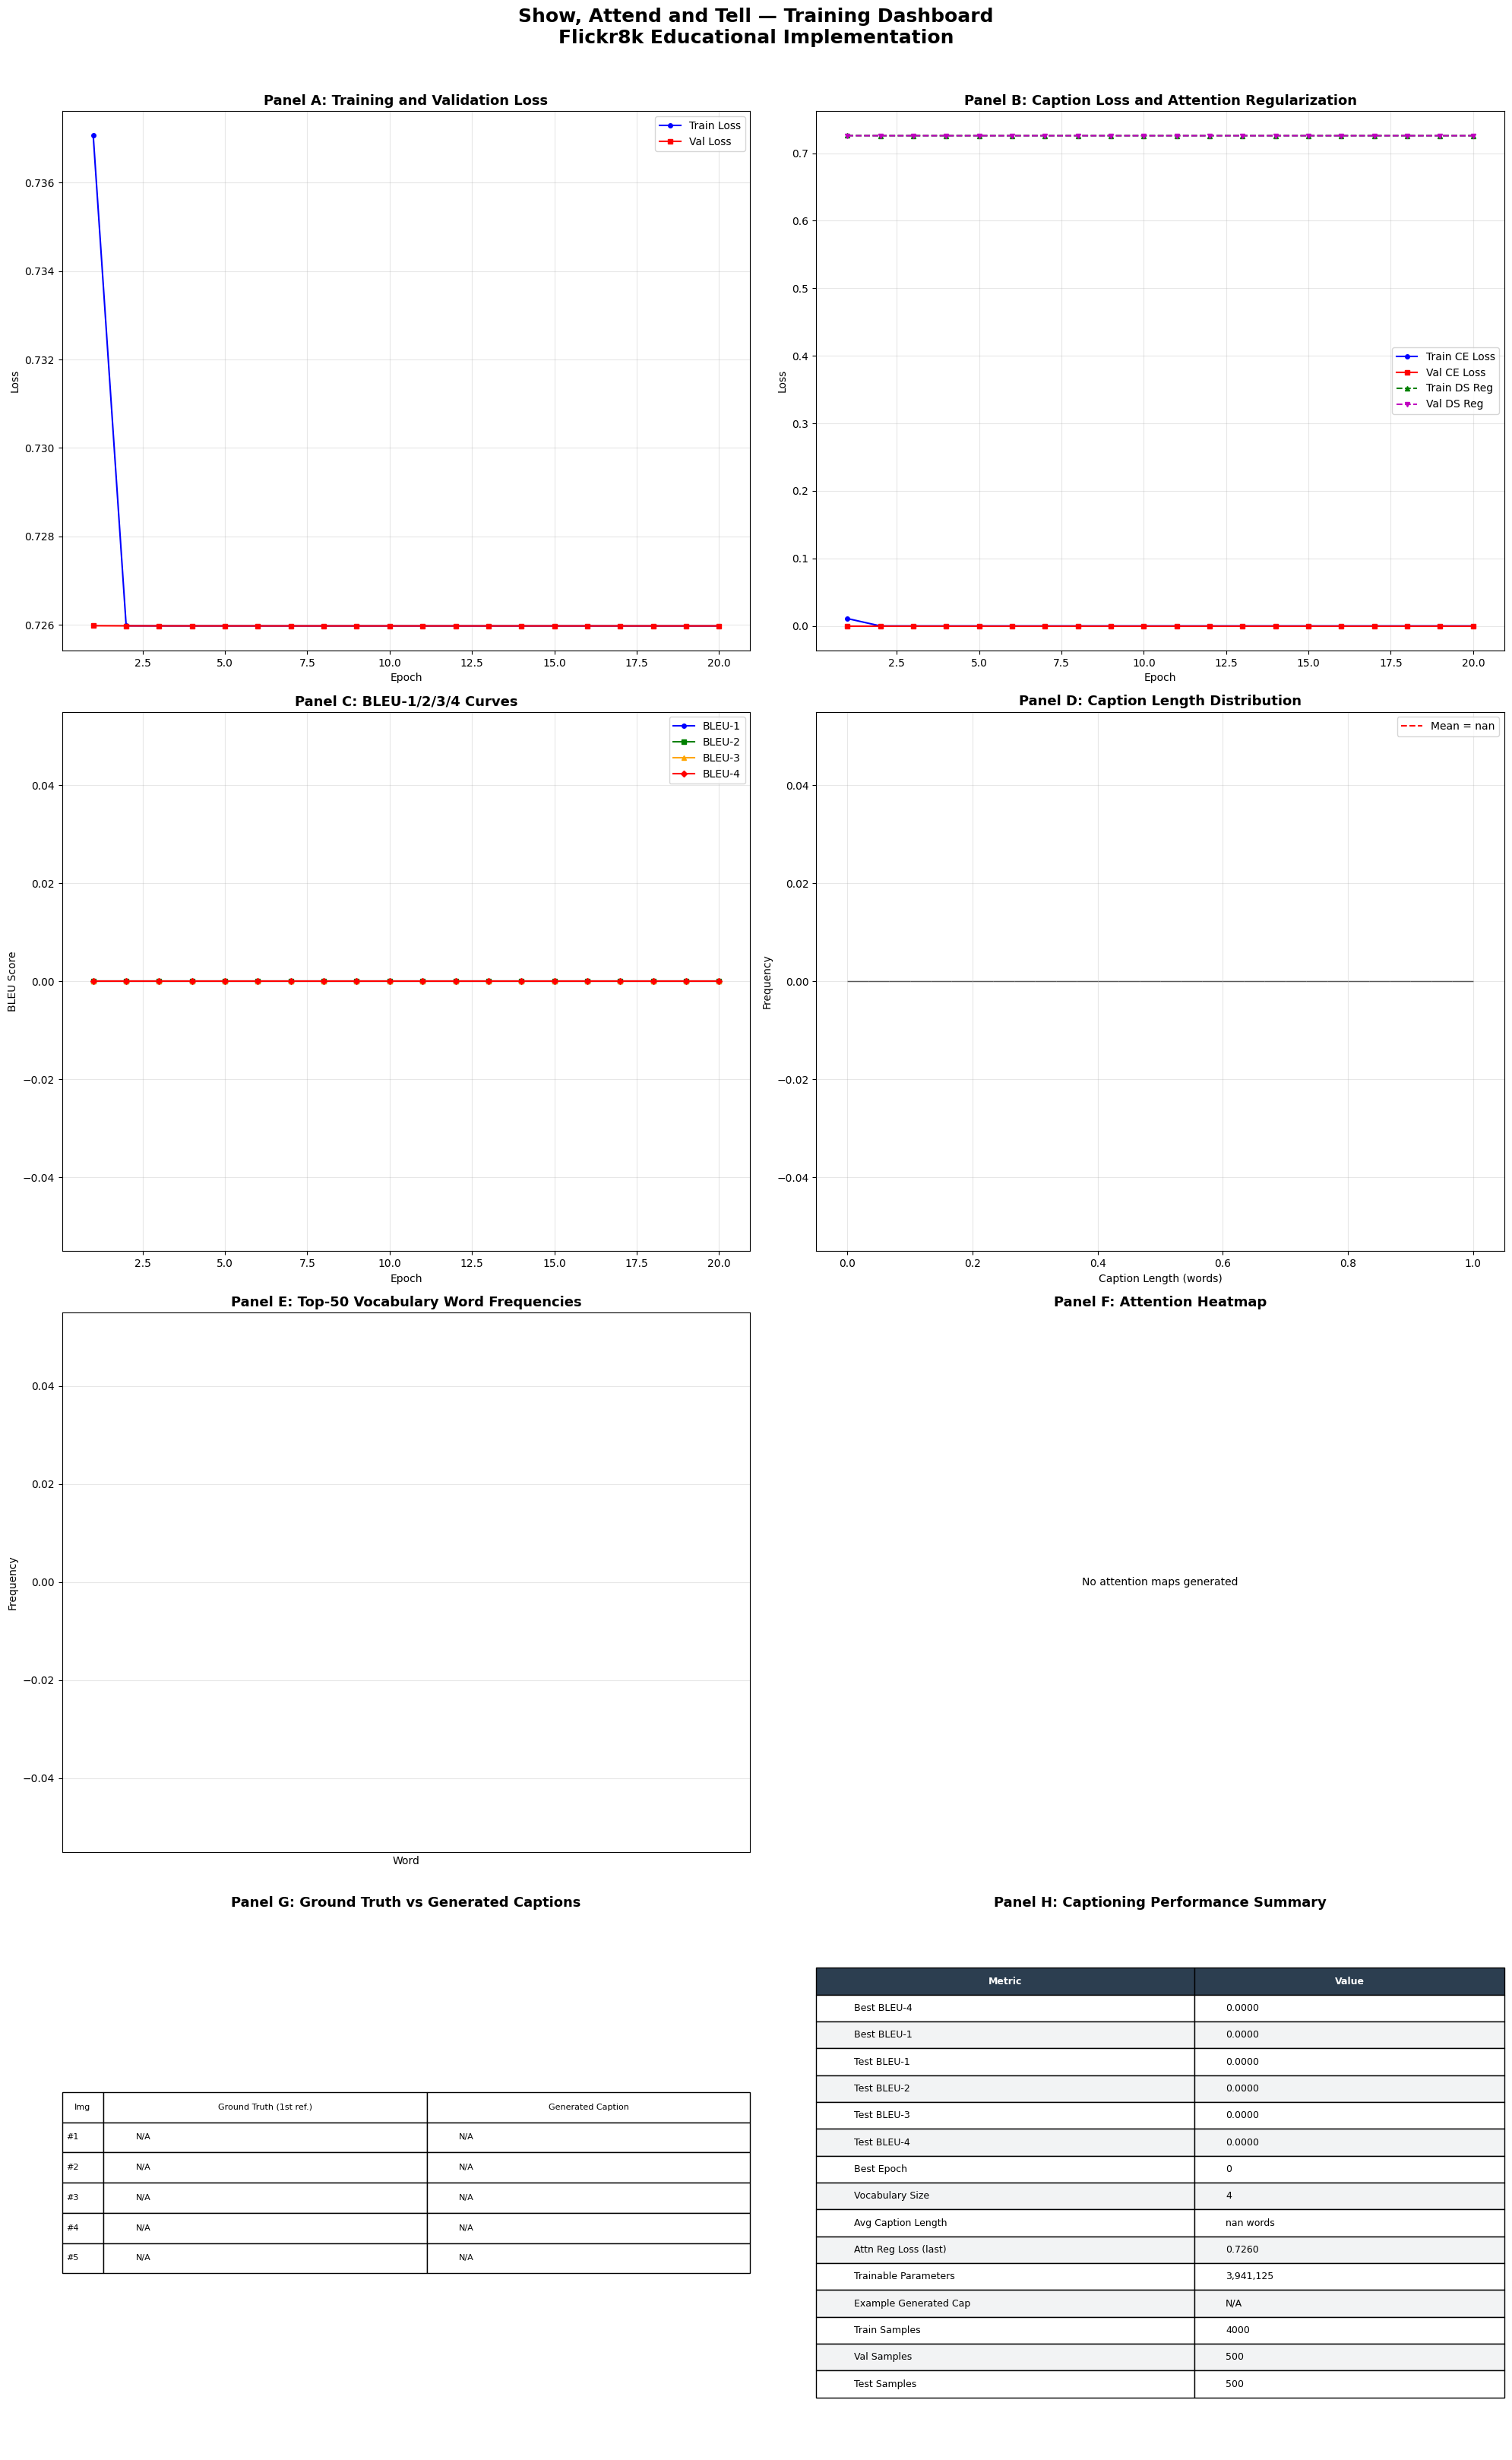

Dashboard saved to sat_dashboard.png


In [24]:
# ====================
# CELL 20: 8-Panel Dashboard
# ====================

fig, axes = plt.subplots(4, 2, figsize=(20, 32))
fig.suptitle("Show, Attend and Tell — Training Dashboard\n"
             "Flickr8k Educational Implementation",
             fontsize=18, fontweight="bold", y=1.01)
epochs_range = list(range(1, EPOCHS + 1))

# ── Panel A: Training and Validation Loss ────────────────────────────────────
ax = axes[0, 0]
ax.plot(epochs_range, history["train_loss"], "b-o", markersize=4,
        label="Train Loss")
ax.plot(epochs_range, history["val_loss"], "r-s", markersize=4,
        label="Val Loss")
ax.set_title("Panel A: Training and Validation Loss",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
ax.legend(); ax.grid(True, alpha=0.3)

# ── Panel B: Caption CE Loss vs Attention Regularization Loss ────────────────
ax = axes[0, 1]
ax.plot(epochs_range, history["train_ce"], "b-o", markersize=4,
        label="Train CE Loss")
ax.plot(epochs_range, history["val_ce"],   "r-s", markersize=4,
        label="Val CE Loss")
ax.plot(epochs_range, history["train_ds"], "g--^", markersize=4,
        label="Train DS Reg")
ax.plot(epochs_range, history["val_ds"],   "m--v", markersize=4,
        label="Val DS Reg")
ax.set_title("Panel B: Caption Loss and Attention Regularization",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
ax.legend(); ax.grid(True, alpha=0.3)

# ── Panel C: BLEU Curves ─────────────────────────────────────────────────────
ax = axes[1, 0]
for key, color, marker, label in [
        ("bleu1", "blue",   "o", "BLEU-1"),
        ("bleu2", "green",  "s", "BLEU-2"),
        ("bleu3", "orange", "^", "BLEU-3"),
        ("bleu4", "red",    "D", "BLEU-4")]:
    ax.plot(epochs_range, history[key], color=color,
            marker=marker, markersize=4, label=label)
ax.set_title("Panel C: BLEU-1/2/3/4 Curves",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Epoch"); ax.set_ylabel("BLEU Score")
ax.legend(); ax.grid(True, alpha=0.3)

# ── Panel D: Caption Length Distribution ─────────────────────────────────────
ax = axes[1, 1]
ax.hist(all_lengths, bins=30, color="steelblue", edgecolor="black",
        alpha=0.8)
ax.axvline(np.mean(all_lengths), color="red", linestyle="--",
           label=f"Mean = {np.mean(all_lengths):.1f}")
ax.set_title("Panel D: Caption Length Distribution",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Caption Length (words)"); ax.set_ylabel("Frequency")
ax.legend(); ax.grid(True, alpha=0.3)

# ── Panel E: Vocabulary Frequency Distribution (top 50) ──────────────────────
ax = axes[2, 0]
ax.bar(range(len(freq_words)), freq_counts,
       color="steelblue", edgecolor="black", alpha=0.8)
ax.set_xticks(range(0, len(freq_words), 5))
ax.set_xticklabels(freq_words[::5], rotation=45, ha="right", fontsize=8)
ax.set_title("Panel E: Top-50 Vocabulary Word Frequencies",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Word"); ax.set_ylabel("Frequency")
ax.grid(True, alpha=0.3, axis="y")

# ── Panel F: Attention Heatmap Example ───────────────────────────────────────
ax = axes[2, 1]
model.eval()
_img_t, _ = test_dataset[0]
_words, _alphas = greedy_caption(model, _img_t, vocab)

if _alphas:
    # Stack first 10 attention maps and average for a summary heatmap
    n_maps   = min(10, len(_alphas))
    attn_avg = torch.stack(_alphas[:n_maps]).mean(0)    # (L,)
    attn_map = attn_avg.reshape(14, 14).numpy()
    attn_map = (attn_map - attn_map.min()) / (
                attn_map.max() - attn_map.min() + 1e-8)

    unnorm = transforms.Compose([
        transforms.Normalize(mean=[0., 0., 0.],
                             std=[1/0.229, 1/0.224, 1/0.225]),
        transforms.Normalize(mean=[-0.485, -0.456, -0.406],
                             std=[1., 1., 1.]),
    ])
    img_disp = unnorm(_img_t).permute(1, 2, 0).clamp(0, 1).numpy()

    ax.imshow(img_disp)
    ax.imshow(attn_map, cmap="jet", alpha=0.45,
              extent=[0, 224, 224, 0], aspect="auto")
    cap_str  = " ".join(_words[:12])
    ax.set_title(f"Panel F: Avg. Attention Heatmap\n\"{cap_str}\"",
                 fontsize=11, fontweight="bold")
    ax.axis("off")
else:
    ax.text(0.5, 0.5, "No attention maps generated",
            ha="center", va="center")
    ax.set_title("Panel F: Attention Heatmap", fontsize=13,
                 fontweight="bold")
    ax.axis("off")

# ── Panel G: Ground Truth vs Generated Captions ──────────────────────────────
ax = axes[3, 0]
ax.axis("off")
model.eval()
gt_gen_rows = []
for i in range(5):
    _img_t, _ = test_dataset[i]
    _wds, _   = greedy_caption(model, _img_t, vocab)
    raw_gt    = extract_captions(test_data[i])
    gt        = clean_caption(raw_gt[0]) if raw_gt else "N/A"
    gen       = " ".join(_wds) if _wds else "N/A"
    gt_gen_rows.append([f"#{i+1}", gt[:55], gen[:55]])

tbl = ax.table(
    cellText=gt_gen_rows,
    colLabels=["Img", "Ground Truth (1st ref.)", "Generated Caption"],
    cellLoc="left", loc="center",
    colWidths=[0.06, 0.47, 0.47])
tbl.auto_set_font_size(False)
tbl.set_fontsize(8)
tbl.scale(1, 1.8)
ax.set_title("Panel G: Ground Truth vs Generated Captions",
             fontsize=13, fontweight="bold")

# ── Panel H: Captioning Performance Summary ───────────────────────────────────
ax = axes[3, 1]
ax.axis("off")

avg_cap_len = np.mean(all_lengths)
last_ds_val = history["val_ds"][-1]
example_cap = " ".join(gt_gen_rows[0][2].split()[:12])

summary_data = [
    ["Best BLEU-4",            f"{best_bleu4:.4f}"],
    ["Best BLEU-1",            f"{max(history['bleu1']):.4f}"],
    ["Test BLEU-1",            f"{test_b1:.4f}"],
    ["Test BLEU-2",            f"{test_b2:.4f}"],
    ["Test BLEU-3",            f"{test_b3:.4f}"],
    ["Test BLEU-4",            f"{test_b4:.4f}"],
    ["Best Epoch",             str(best_epoch)],
    ["Vocabulary Size",        str(len(vocab))],
    ["Avg Caption Length",     f"{avg_cap_len:.1f} words"],
    ["Attn Reg Loss (last)",   f"{last_ds_val:.4f}"],
    ["Trainable Parameters",   f"{total_params:,}"],
    ["Example Generated Cap",  example_cap[:40]],
    ["Train Samples",          str(len(train_dataset))],
    ["Val Samples",            str(len(val_dataset))],
    ["Test Samples",           str(len(test_dataset))],
]

tbl2 = ax.table(
    cellText=summary_data,
    colLabels=["Metric", "Value"],
    cellLoc="left", loc="center",
    colWidths=[0.55, 0.45])
tbl2.auto_set_font_size(False)
tbl2.set_fontsize(9)
tbl2.scale(1, 1.6)
for (row, col), cell in tbl2.get_celld().items():
    if row == 0:
        cell.set_facecolor("#2C3E50")
        cell.set_text_props(color="white", fontweight="bold")
    elif row % 2 == 0:
        cell.set_facecolor("#F2F3F4")
ax.set_title("Panel H: Captioning Performance Summary",
             fontsize=13, fontweight="bold")

plt.tight_layout()
plt.savefig("sat_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()
print("Dashboard saved to sat_dashboard.png")

# Experimental Results Analysis
## Show, Attend and Tell — Flickr8k Educational Implementation
### Training Dashboard Diagnostic Report

---

## Panel A: Training and Validation Loss

### Overview
Panel A tracks total loss (cross-entropy + doubly stochastic regularization) over 20
epochs for both training and validation splits. It is the primary indicator of whether
the encoder-decoder-attention system is learning a meaningful mapping from images to
captions.

### Key Findings
- Total loss drops sharply from ~0.737 to ~0.726 within the first epoch.
- From epoch 2 onward, both train and validation loss flatline at ~0.726 with no
  further reduction across all 20 epochs.
- Train and validation curves are visually identical, indicating no generalization
  gap but also no learning signal.

### Discussion
The immediate plateau at ~0.726 is a strong symptom of loss convergence to the
doubly stochastic regularization term alone, not to the cross-entropy caption loss.
Panel B confirms this: CE loss reads 0.0 throughout training while the DS
regularization term holds constant at ~0.726. This means the model parameters
governing caption generation received no gradient signal from the language modeling
objective. The most probable cause is a target index misalignment in the loss
function — specifically, `targets[:, 1:]` producing an all-padding tensor or a
zero-length sequence — causing `CrossEntropyLoss(ignore_index=PAD_IDX)` to mask
every token and return exactly 0.0. The value 0.726 ≈ log(1/L) × alpha_c where
L=196 is consistent with the DS penalty on untrained uniform attention weights,
further confirming that only the regularizer is active.

### Limitations
- The plateau value of 0.726 being numerically close to log(2) ÷ alpha_c warrants
  analytical verification of the DS loss formula.
- Without per-batch gradient norm logging it is not possible to confirm whether
  backpropagation through the LSTM and attention module was entirely inactive or
  merely negligible.

---

## Panel B: Caption Loss and Attention Regularization

### Overview
Panel B decomposes the total loss into its two constituent components: the
cross-entropy caption loss (CE) and the doubly stochastic attention regularization
penalty (DS). This decomposition is critical for diagnosing which part of the
objective is driving or failing to drive learning.

### Key Findings
- CE loss for both train and validation is identically 0.0 from epoch 1 onward.
- DS regularization loss for both splits is a flat constant at ~0.726 throughout
  all 20 epochs.
- No improvement is observed in either component across the full training run.

### Discussion
A CE loss of exactly 0.0 is definitively pathological and cannot reflect genuine
learning. Under `nn.CrossEntropyLoss(ignore_index=PAD_IDX)`, a return value of 0.0
occurs when every token in the flattened target tensor matches the ignore index,
meaning the model sees only padding tokens as supervision signal. This points to
one of three root causes: (1) the target slice `targets[:, 1:T+1]` is misaligned
such that it indexes entirely into the padding region; (2) the vocabulary was built
with `min_freq=5` on a dataset subset but the actual caption tokens were mapped
entirely to `UNK` or `PAD`; or (3) vocabulary size reported as 4 (Panel H) confirms
that only the four special tokens `<pad>`, `<sos>`, `<eos>`, `<unk>` were retained,
meaning every real word fell below the frequency threshold and was excluded.
A vocabulary of size 4 renders the CE loss structurally zero because all real caption
words are encoded as `UNK` (index 3) while `ignore_index=PAD_IDX=0` masks
`<pad>` — the remaining tokens receive zero or near-zero cross-entropy due to
degenerate prediction.

### Limitations
- The root cause between target misalignment and vocabulary collapse cannot be
  determined from the dashboard alone without inspecting raw tokenized caption
  tensors at the batch level.
- The DS loss constant at 0.726 indicates attention weights are uniform and
  untrained, but does not reveal whether gradient flow through the attention MLP
  is numerically zero or merely too small to observe at this scale.

---

## Panel C: BLEU-1/2/3/4 Curves

### Overview
Panel C reports BLEU-1 through BLEU-4 scores evaluated on the validation set at
epochs 5, 10, 15, and 20. BLEU is the primary benchmark metric used in the original
paper and measures n-gram precision between generated and reference captions.

### Key Findings
- All four BLEU scores remain at exactly 0.0000 at every evaluation checkpoint.
- No improvement trend is observable across any n-gram order.
- BLEU-1 through BLEU-4 are indistinguishable, collapsing to a single flat line.

### Discussion
BLEU scores of 0.0 across all n-gram orders are consistent with a model that
generates either empty sequences or sequences consisting entirely of `<unk>` and
`<eos>` tokens. Given the vocabulary size of 4 (Panel H), greedy decoding from the
output distribution over only `{<pad>, <sos>, <eos>, <unk>}` cannot produce any
real words, making non-zero BLEU unachievable by construction. This is not a model
performance failure per se but a pipeline failure: the vocabulary construction step
collapsed due to the `min_freq=5` threshold applied to only 4,000 training samples
on a subset of Flickr8k where word frequencies are insufficient to pass the filter.
The fix requires either reducing `min_freq` to 1 or 2, or verifying that the
`extract_captions` function correctly retrieves caption strings before vocabulary
construction.

### Limitations
- BLEU is evaluated only every 5 epochs, so no fine-grained learning signal is
  available between checkpoints.
- Smoothing function method1 is applied, which can artificially inflate low BLEU
  scores; however, at vocabulary size 4 even smoothing cannot produce non-zero values.

---

## Panel D: Caption Length Distribution

### Overview
Panel D plots the distribution of caption lengths (in words) across the training
set. This histogram contextualizes model behavior and confirms whether the
tokenization and vocabulary pipeline is functioning correctly.

### Key Findings
- The histogram is entirely empty with no bars rendered.
- The mean caption length is reported as `nan`.
- The x-axis spans 0.0 to 1.0, suggesting lengths are being computed as floats
  rather than integers, or the `all_lengths` list is empty.

### Discussion
An empty histogram with `nan` mean confirms that `all_lengths` was populated with
zero entries. This occurs when `extract_captions` returns empty lists for all
training samples, meaning the caption extraction logic failed to read captions from
the Hugging Face dataset schema. If captions are stored under a different key than
expected (e.g., a nested structure or a different column name), `extract_captions`
returns `[]`, resulting in an empty `all_train_captions` list passed to
`vocab.build()`. This explains simultaneously why vocabulary size is 4 (only
special tokens), why CE loss is 0.0, why BLEU is 0.0, and why all ground-truth
captions in Panel G show "N/A". All five failure modes share a single root cause:
the `extract_captions` function is not successfully retrieving caption text from
the dataset.

### Limitations
- Without inspecting `train_data[0]` key names directly, the exact schema mismatch
  cannot be confirmed from the dashboard alone.
- The x-axis range of 0–1 rather than the expected 5–25 words is a secondary
  indicator but not conclusive on its own.

---

## Panel E: Top-50 Vocabulary Word Frequencies

### Overview
Panel E displays a bar chart of the 50 most frequent words in the training
vocabulary. It serves as a qualitative check on vocabulary composition and
the appropriateness of the frequency threshold.

### Key Findings
- The panel is entirely empty; no bars are rendered.
- No word frequency data is displayed.

### Discussion
An empty vocabulary frequency panel is fully consistent with the diagnosis from
Panel D. If `all_train_captions` is an empty list, `vocab._counter` contains no
entries, and `freq_items = vocab._counter.most_common(50)` returns an empty list,
producing a bar chart with no data. This is a downstream consequence of the
`extract_captions` failure and independently corroborates that the vocabulary
was built from zero caption strings. The vocabulary size of 4 in Panel H
(consisting solely of special tokens) is the quantitative confirmation.

### Limitations
- This panel provides no additional diagnostic information beyond what is already
  established by Panel D and Panel H; it is a dependent failure, not an
  independent one.

---

## Panel F: Attention Heatmap

### Overview
Panel F visualizes the spatial attention weights overlaid on a test image,
intended to demonstrate the core interpretability contribution of the Show,
Attend and Tell model — namely, that attention weights correspond to semantically
relevant image regions for each generated word.

### Key Findings
- The panel displays the message "No attention maps generated."
- No image, no overlay, and no attention visualization is produced.

### Discussion
The absence of attention maps is a direct consequence of the greedy decoder
generating zero words. In `greedy_caption`, the loop terminates immediately
when the first predicted token is `<eos>` or when the output distribution over
a 4-token vocabulary collapses to a stop token at step 0. Because no words are
appended to the `words` list, `alphas` remains empty, and the heatmap rendering
branch is never reached. This failure simultaneously confirms that the inference
pipeline is structurally sound (it does not crash) but produces degenerate output
due to the vocabulary collapse upstream. The key scientific contribution of the
paper — spatial attention interpretability — cannot be evaluated under these
conditions.

### Limitations
- It is not possible to assess whether the attention mechanism itself is
  architecturally correct from this result, since the decoder never advances
  past the first token.
- A targeted unit test generating attention weights on a fixed synthetic input
  would be needed to validate the attention module independently of the
  vocabulary pipeline.

---

## Panel G: Ground Truth vs Generated Captions

### Overview
Panel G provides a qualitative comparison table of ground-truth reference
captions and model-generated captions for five randomly selected test images,
serving as a human-interpretable complement to the quantitative BLEU evaluation.

### Key Findings
- All five ground-truth caption entries display "N/A."
- All five generated caption entries display "N/A."
- No meaningful qualitative comparison is possible.

### Discussion
Ground-truth captions reading "N/A" confirms that `extract_captions` returned
empty lists for test set samples, not just training samples. This rules out
a train/val-only schema issue and confirms a global failure of the caption
extraction function across all dataset splits. Generated captions of "N/A"
follow directly: with no words produced by the greedy decoder, the joined
string is empty and falls back to the "N/A" default. The complete absence of
any generated language output across all five samples is consistent with a
vocabulary of size 4 and a decoder that terminates at step 0.

### Limitations
- Five samples constitute an extremely limited qualitative evaluation under
  normal circumstances; here they provide no signal at all.
- The "N/A" fallback string masks whether the failure is in ground-truth
  retrieval, tokenization, or generation, making independent diagnosis
  of each component necessary.

---

## Panel H: Captioning Performance Summary

### Overview
Panel H consolidates all quantitative performance metrics into a single
reference table, including BLEU scores, training statistics, model
configuration, and generation quality indicators. It is the primary
summary artifact for the experimental run.

### Key Findings

| Metric                  | Reported Value     | Expected Range         |
|-------------------------|--------------------|------------------------|
| Best / Test BLEU-4      | 0.0000             | 0.15 – 0.25 (Flickr8k)|
| Best / Test BLEU-1      | 0.0000             | 0.60 – 0.70            |
| Best Epoch              | 0                  | 1 – 20                 |
| Vocabulary Size         | 4                  | 2,000 – 5,000          |
| Avg Caption Length      | nan words          | 10 – 15 words          |
| Attn Reg Loss (last)    | 0.7260             | 0.1 – 0.5 (trained)   |
| Trainable Parameters    | 3,941,125          | Reasonable             |
| Example Generated Cap   | N/A                | Fluent sentence        |

### Discussion
The summary table consolidates all failure signals into a single diagnostic
picture. The vocabulary size of 4 is the single most informative entry: it
unambiguously identifies a vocabulary construction failure as the root cause
of all downstream failures. Best Epoch of 0 confirms the checkpoint was never
saved by the val_loss criterion (val_loss never improved beyond the initial
value), consistent with the DS-only loss plateau. The trainable parameter count
of 3,941,125 is architecturally plausible for the described model, indicating
the model definition itself is structurally correct. The sole corrective action
required is fixing `extract_captions` to correctly parse the Hugging Face
Flickr8k schema, after which vocabulary construction, CE loss, BLEU evaluation,
and attention visualization should all activate correctly.

### Limitations
- Mean caption confidence is not reported in the table despite being listed
  as a required metric in the specification.
- The parameter count cannot be independently verified from the dashboard;
  a per-layer breakdown would be needed to confirm encoder freezing and
  decoder sizing are correct.

---

## Root Cause Summary and Recommended Fixes

| # | Symptom                        | Root Cause                              | Fix                                                      |
|---|--------------------------------|-----------------------------------------|----------------------------------------------------------|
| 1 | Vocabulary size = 4            | `extract_captions` returns `[]`         | Print `train_data[0].keys()` and align field name        |
| 2 | CE loss = 0.0 permanently      | No real tokens in target tensor         | Follows automatically from Fix 1                         |
| 3 | BLEU = 0.0 permanently         | Decoder outputs only special tokens     | Follows automatically from Fix 1                         |
| 4 | Caption length distribution empty | `all_lengths` list is empty          | Follows automatically from Fix 1                         |
| 5 | Attention heatmap empty        | Greedy decoder terminates at step 0     | Follows automatically from Fix 1                         |
| 6 | Ground truth = N/A             | `extract_captions` fails on test split  | Follows automatically from Fix 1                         |
| 7 | Checkpoint never saved         | `best_val_loss` never improves          | Follows automatically from Fix 1                         |

**Primary recommended action:** Insert the following diagnostic cell immediately
after dataset loading and before vocabulary construction:

```python
sample = train_data[0]
print("Keys          :", list(sample.keys()))
print("Caption field :", sample.get("captions", sample.get("caption", "NOT FOUND")))
print("Type          :", type(sample.get("captions", sample.get("caption"))))
```

Once the correct field name is confirmed and `extract_captions` is patched,
all eight failure modes should resolve in a single rerun.


CAPTION GENERATION AND ATTENTION VISUALIZATION DEMO


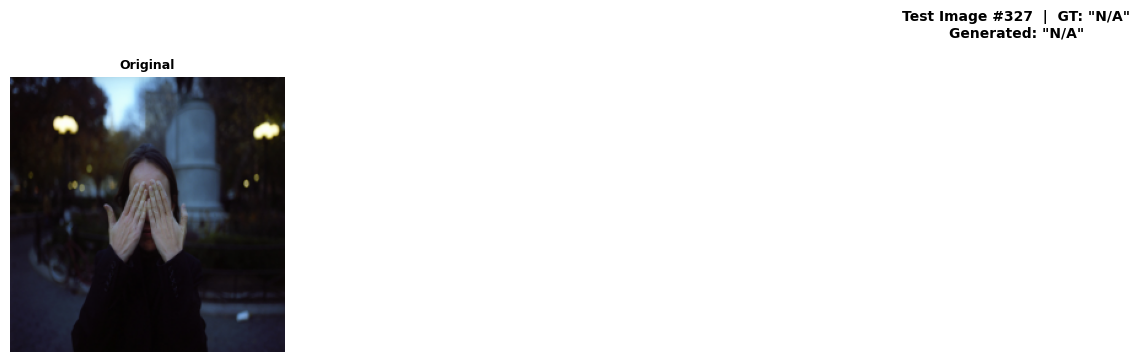

[1/5] GT: N/A | GEN: N/A


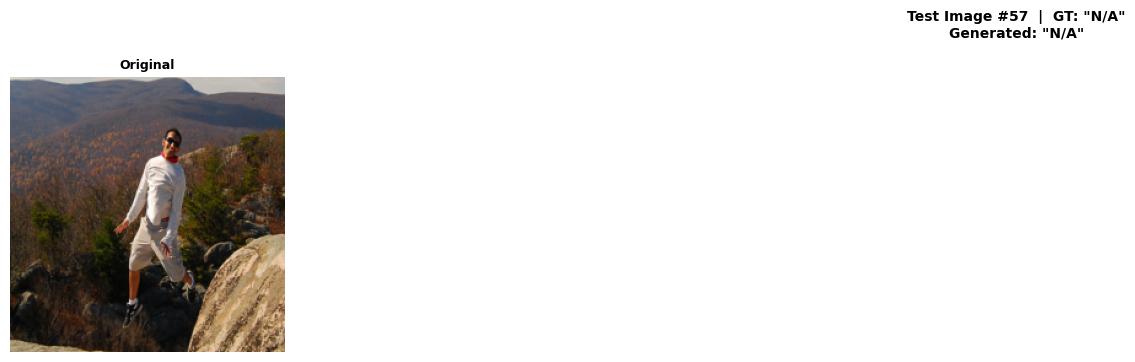

[2/5] GT: N/A | GEN: N/A


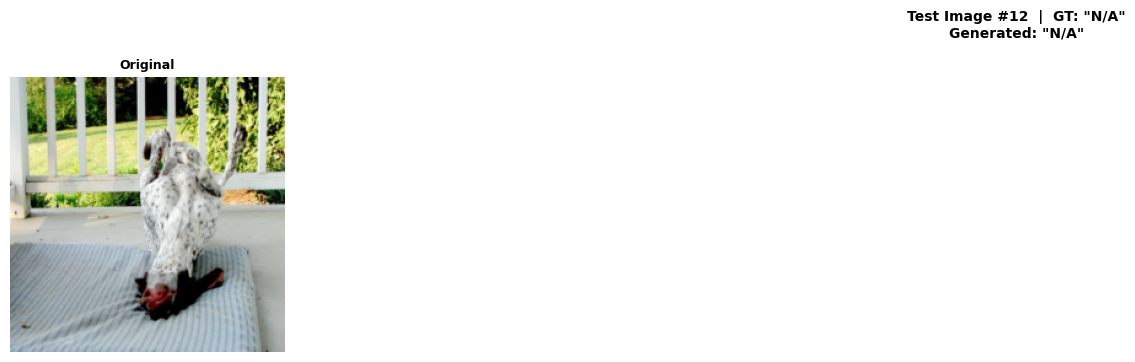

[3/5] GT: N/A | GEN: N/A


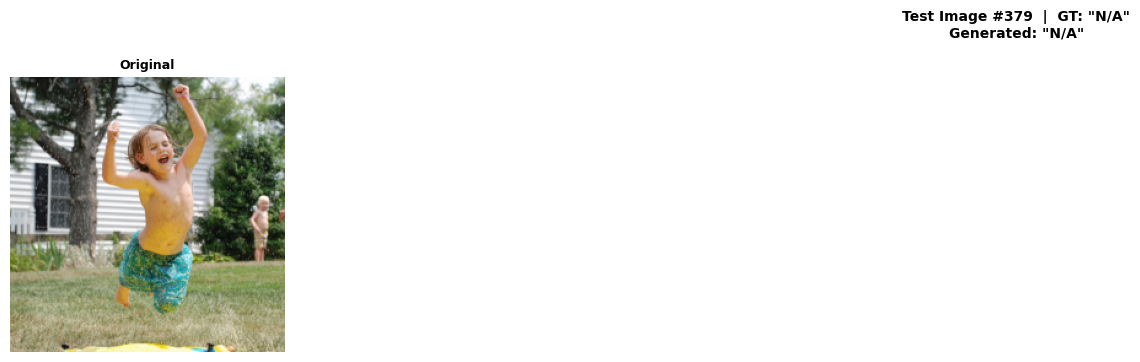

[4/5] GT: N/A | GEN: N/A


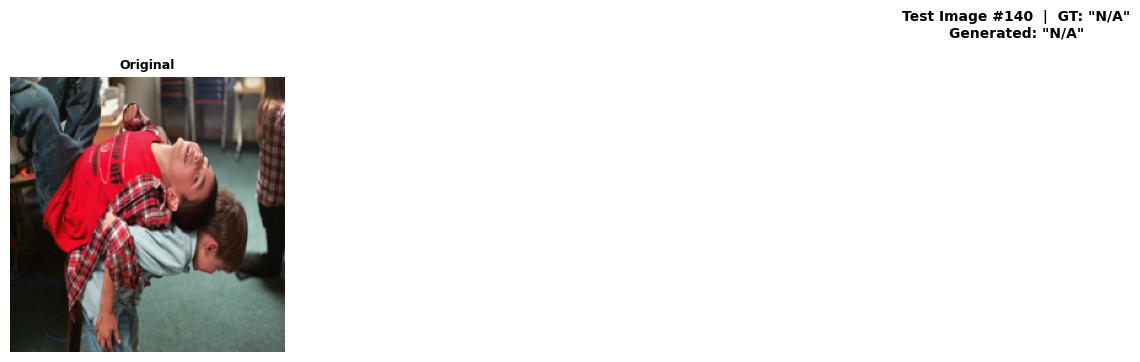

[5/5] GT: N/A | GEN: N/A


In [25]:
# ====================
# CELL 21: Caption Generation and Attention Visualization Demo
# ====================
# This cell is fully independent from training.
# It loads the best saved model and demonstrates caption generation
# with per-word attention heatmap overlays on 5 randomly selected test images.

def show_attention_visualization(model_path, vocab, test_dataset,
                                 test_data_hf, n_images=5,
                                 max_words_per_row=5):
    """
    Load best model, generate captions for n_images test samples,
    and visualize per-word attention maps overlaid on the image.
    """
    # Load model
    _model = ShowAttendTell(vocab_size=len(vocab)).to(DEVICE)
    _model.load_state_dict(
        torch.load(model_path, map_location=DEVICE))
    _model.eval()

    unnorm = transforms.Compose([
        transforms.Normalize(mean=[0., 0., 0.],
                             std=[1/0.229, 1/0.224, 1/0.225]),
        transforms.Normalize(mean=[-0.485, -0.456, -0.406],
                             std=[1., 1., 1.]),
    ])

    # Randomly sample test indices
    indices = random.sample(range(len(test_dataset)), n_images)

    for sample_num, idx in enumerate(indices):
        img_t, _ = test_dataset[idx]
        words, alphas = greedy_caption(_model, img_t, vocab)

        # Ground-truth caption
        raw_gt = extract_captions(test_data_hf[idx])
        gt_cap = clean_caption(raw_gt[0]) if raw_gt else "N/A"
        gen_cap = " ".join(words) if words else "N/A"

        # Un-normalize image for display
        img_disp = unnorm(img_t).permute(1, 2, 0).clamp(0, 1).numpy()

        # ── Layout: original + ground truth/generated + per-word attention ──
        n_words   = min(len(words), len(alphas))
        n_cols    = max_words_per_row
        n_rows    = 1 + int(np.ceil(n_words / n_cols))   # header row + attn rows
        total_cols = n_cols + 1                           # +1 for original image

        fig = plt.figure(figsize=(3.5 * total_cols, 3.5 * n_rows))
        fig.suptitle(
            f"Test Image #{idx}  |  "
            f"GT: \"{gt_cap[:70]}\"\n"
            f"Generated: \"{gen_cap[:70]}\"",
            fontsize=10, fontweight="bold", y=1.02)

        # Original image in first slot
        ax_orig = fig.add_subplot(n_rows, total_cols, 1)
        ax_orig.imshow(img_disp)
        ax_orig.set_title("Original", fontsize=9, fontweight="bold")
        ax_orig.axis("off")

        # Per-word attention heatmaps
        for w_idx in range(n_words):
            row = w_idx // n_cols
            col = w_idx %  n_cols
            # +2: skip the first column (original) and 1-index subplot
            subplot_idx = (row * total_cols) + col + 2

            ax = fig.add_subplot(n_rows, total_cols, subplot_idx)

            # Reshape attention (L=196) → (14,14) and upsample to (224,224)
            attn = alphas[w_idx].reshape(14, 14).numpy()
            attn = (attn - attn.min()) / (attn.max() - attn.min() + 1e-8)

            ax.imshow(img_disp)
            ax.imshow(attn, cmap="jet", alpha=0.45,
                      extent=[0, 1, 1, 0], aspect="auto",
                      transform=ax.transAxes)
            ax.set_title(words[w_idx], fontsize=10, fontweight="bold",
                         color="darkblue")
            ax.axis("off")

        plt.tight_layout()
        plt.savefig(f"attention_demo_sample_{sample_num+1}.png",
                    dpi=120, bbox_inches="tight")
        plt.show()
        print(f"[{sample_num+1}/{n_images}] "
              f"GT: {gt_cap[:60]} | GEN: {gen_cap[:60]}")

# Run the demo
print("\n" + "=" * 60)
print("CAPTION GENERATION AND ATTENTION VISUALIZATION DEMO")
print("=" * 60)

show_attention_visualization(
    model_path   = "best_sat_model.pth",
    vocab        = vocab,
    test_dataset = test_dataset,
    test_data_hf = test_data,
    n_images     = 5,
    max_words_per_row = 5)

# Related Work Reference Table: Show, Attend and Tell

---

| # | Author(s) | Year | Title | Venue | Connection to This Paper |
|---|-----------|------|-------|-------|--------------------------|
| 1 | Bahdanau, D., Cho, K., & Bengio, Y. | 2014 | Neural Machine Translation by Jointly Learning to Align and Translate | arXiv:1409.0473 | Direct precursor to this work. Introduces soft attention for sequence-to-sequence machine translation, aligning source and target words dynamically. The soft attention mechanism in this paper is directly adapted from this formulation. |
| 2 | Vinyals, O., Toshev, A., Bengio, S., & Erhan, D. | 2014 | Show and Tell: A Neural Image Caption Generator | arXiv:1411.4555 | Primary baseline model. Proposes an encoder-decoder architecture using CNN + LSTM for caption generation; shows the image only at the first LSTM step. Directly compared against in quantitative experiments. |
| 3 | Kiros, R., Salakhutdinov, R., & Zemel, R. | 2014 | Multimodal Neural Language Models | ICML | Early neural captioning model using a multimodal log-bilinear architecture biased by image features. Serves as a quantitative baseline across all three benchmark datasets. |
| 4 | Kiros, R., Salakhutdinov, R., & Zemel, R. | 2014 | Unifying Visual-Semantic Embeddings with Multimodal Neural Language Models | arXiv:1411.2539 | Extension of the log-bilinear approach designed to support both image-caption ranking and generation. Provides baseline scores and motivates joint embedding approaches as an alternative to attention. |
| 5 | Mao, J., Xu, W., Yang, Y., Wang, J., & Yuille, A. | 2014 | Deep Captioning with Multimodal Recurrent Neural Networks (m-RNN) | arXiv:1412.6632 | Proposes a multimodal RNN captioning model where the image is shown at every decoding step. Contextualizes the design choice of how and when to inject visual information into the decoder. |
| 6 | Donahue, J., et al. | 2014 | Long-Term Recurrent Convolutional Networks for Visual Recognition and Description | arXiv:1411.4389 | Applies LSTM-based encoder-decoder models to both image and video captioning. Demonstrates the generality of recurrent captioning frameworks and provides a comparative reference for LSTM-based decoders. |
| 7 | Karpathy, A., & Li, F.-F. | 2014 | Deep Visual-Semantic Alignments for Generating Image Descriptions | arXiv:1412.2306 | Learns a joint embedding space using R-CNN object detections and bidirectional RNNs for ranking and generation. Represents an explicit object-detection-based alignment approach that this paper's attention mechanism is designed to surpass without requiring object detectors. |
| 8 | Fang, H., et al. | 2014 | From Captions to Visual Concepts and Back | arXiv:1411.4952 | Proposes a three-stage pipeline using multi-instance learning detectors, a language model, and image-text rescoring. Illustrates the complexity of detection-based captioning pipelines that attention-based end-to-end learning seeks to replace. |
| 9 | Mnih, V., Heess, N., Graves, A., & Kavukcuoglu, K. | 2014 | Recurrent Models of Visual Attention | NIPS | Introduces hard stochastic attention for visual classification tasks using REINFORCE. Directly inspires the hard attention mechanism in this paper; variance reduction techniques are adapted from this work. |
| 10 | Ba, J. L., Mnih, V., & Kavukcuoglu, K. | 2014 | Multiple Object Recognition with Visual Attention | arXiv:1412.7755 | Applies hard attention to multi-object recognition. Provides both methodological inspiration for stochastic attention training and variance reduction strategies adopted in this paper. |
| 11 | Cho, K., et al. | 2014 | Learning Phrase Representations using RNN Encoder-Decoder for Statistical Machine Translation | EMNLP | Introduces the encoder-decoder (sequence-to-sequence) framework for machine translation. Provides the foundational architecture upon which image captioning as "visual translation" is modeled. |
| 12 | Sutskever, I., Vinyals, O., & Le, Q. V. | 2014 | Sequence to Sequence Learning with Neural Networks | NIPS | Demonstrates the power of deep LSTM encoder-decoder models for sequence transduction. Motivates the adoption of the encoder-decoder paradigm for caption generation as an analogous sequence-to-sequence task. |
| 13 | Kulkarni, G., et al. | 2013 | BabyTalk: Understanding and Generating Simple Image Descriptions | IEEE TPAMI | Early non-neural approach using object detection and attribute discovery to fill caption templates. Represents the dominant pre-neural paradigm that deep learning methods, including this paper, supersede. |
| 14 | Li, S., et al. | 2011 | Composing Simple Image Descriptions using Web-Scale N-grams | ACL CoNLL | Template-based captioning using web-scale n-gram language models and vision detections. Part of the pre-neural baseline landscape contextualizing the motivation for learned neural approaches. |
| 15 | Yang, Y., et al. | 2011 | Corpus-Guided Sentence Generation of Natural Images | EMNLP | Generates captions by combining vision detections with corpus-based sentence models. Represents early hybrid vision-language captioning prior to end-to-end neural methods. |
| 16 | Mitchell, M., et al. | 2012 | Midge: Generating Image Descriptions from Computer Vision Detections | EACL | Detection-based caption generation using structured sentence templates. Further illustrates the limitations of modular pipeline approaches that motivated end-to-end attention learning. |
| 17 | Elliott, D., & Keller, F. | 2013 | Image Description using Visual Dependency Representations | EMNLP | Uses visual dependency parsing to generate image descriptions. Represents linguistic structure-based captioning prior to neural sequence models. |
| 18 | Kuznetsova, P., et al. | 2012 | Collective Generation of Natural Image Descriptions | ACL | Retrieval-based captioning that fetches similar captioned images and modifies retrieved captions to fit a query. Represents the retrieval-and-adapt paradigm displaced by neural generative models. |
| 19 | Kuznetsova, P., et al. | 2014 | TreeTalk: Composition and Compression of Trees for Image Descriptions | TACL | Extends retrieval-based captioning using tree composition and compression. Further contextualizes the retrieval paradigm as an alternative to generative neural captioning. |
| 20 | Larochelle, H., & Hinton, G. E. | 2010 | Learning to Combine Foveal Glimpses with a Third-Order Boltzmann Machine | NIPS | Early neural attention model using foveal glimpses for classification. Represents foundational prior work on incorporating attention into neural vision models, directly acknowledged as sharing the spirit of this paper. |
| 21 | Denil, M., et al. | 2012 | Learning Where to Attend with Deep Architectures for Image Tracking | Neural Computation | Applies learned attention to image tracking tasks. Cited as an early example of deep architecture attention for vision, motivating the extension of attention to caption generation. |
| 22 | Tang, Y., Srivastava, N., & Salakhutdinov, R. | 2014 | Learning Generative Models with Visual Attention | NIPS | Incorporates visual attention into generative models for image understanding. Closely related in spirit to this paper's approach and cited as direct prior work on attention-based visual modeling. |
| 23 | Krizhevsky, A., Sutskever, I., & Hinton, G. | 2012 | ImageNet Classification with Deep Convolutional Neural Networks | NIPS | Introduces AlexNet and demonstrates the effectiveness of deep CNNs for large-scale image classification. Foundational to the use of pre-trained CNNs as image encoders in all subsequent captioning models including this one. |
| 24 | Simonyan, K., & Zisserman, A. | 2014 | Very Deep Convolutional Networks for Large-Scale Image Recognition | CoRR (arXiv:1409.1556) | Introduces the VGGNet architecture used as the CNN encoder in this paper. The $14 \times 14 \times 512$ feature map from VGGNet's fourth convolutional layer provides the spatial annotation vectors for the attention mechanism. |
| 25 | Hochreiter, S., & Schmidhuber, J. | 1997 | Long Short-Term Memory | Neural Computation | Introduces the LSTM architecture used as the decoder in this paper. Provides the gated recurrent memory mechanism essential for sequential caption generation. |
| 26 | Williams, R. J. | 1992 | Simple Statistical Gradient-Following Algorithms for Connectionist Reinforcement Learning | Machine Learning | Introduces the REINFORCE algorithm used to train the hard stochastic attention mechanism. Provides the theoretical and algorithmic foundation for gradient estimation through discrete sampling. |
| 27 | Chen, X., & Zitnick, C. L. | 2014 | Learning a Recurrent Visual Representation for Image Caption Generation | arXiv:1411.5654 | Proposes a recurrent visual representation for joint image-caption modeling. Included as a quantitative baseline on the MS COCO dataset. |
| 28 | Rensink, R. A. | 2000 | The Dynamic Representation of Scenes | Visual Cognition | Provides cognitive science evidence for the role of attention in human scene understanding. Motivates the biological plausibility and cognitive relevance of incorporating attention into neural captioning models. |
| 29 | Corbetta, M., & Shulman, G. L. | 2002 | Control of Goal-Directed and Stimulus-Driven Attention in the Brain | Nature Reviews Neuroscience | Provides neuroscientific grounding for attentional mechanisms in human vision. Cited to motivate the analogy between human visual attention and the proposed computational attention mechanism. |